# **Problem Statement**

## **Business Context**

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## **Objective**

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## **Data Description**

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **1 - Installing and Importing the necessary libraries**

In [2]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:**

- Restart the runtime after installing libraries and ignore dependency warnings.

In [3]:
# Supress warnings
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with data manipulation
import numpy as np
import pandas as pd

# Importing utility scikit-learn library for splitting the dataset into subsets, 1 for training the ML model and the other for testing it's performance
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ensemble and Tree-Based Regressors
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
  )

# Pipeline creation
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# Data preprocessing
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# Tuning
from sklearn.model_selection import GridSearchCV


# Serialization
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# Pandas display settings to show all columns and a limited 100 rows
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# **2 - Loading the dataset**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load data
kart = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Project-Model_Deployment/SuperKart.csv")

In [6]:
# Create copy
data = kart.copy()

# **3 - Data Overview**

**3.1 - View sample rows of dataset**

In [7]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [8]:
data.sample(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
3090,FD2928,8.27,Regular,0.145,Snack Foods,116.25,OUT002,1998,Small,Tier 3,Food Mart,1833.36
504,NC7039,10.55,No Sugar,0.041,Household,181.19,OUT004,2009,Medium,Tier 2,Supermarket Type2,3677.59
5034,FD1965,15.98,Low Sugar,0.052,Canned,168.47,OUT001,1987,High,Tier 2,Supermarket Type1,4643.63
3403,FD8348,8.95,Low Sugar,0.129,Meat,113.79,OUT002,1998,Small,Tier 3,Food Mart,1937.49
6181,FD7508,15.35,Low Sugar,0.109,Canned,148.09,OUT001,1987,High,Tier 2,Supermarket Type1,4083.99


In [9]:
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


**3.2 - Shape of the dataset**

In [10]:
data.shape

(8763, 12)

**Observation**

- Dataset has 8763 rows and 12 columns

**3.3 - Check the column data types**

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


**Observation**

- The dataset contains no missing values across all columns.
- The numerical columns identified are: Product_Weight, Product_Allocated_Area, Product_MRP, Store_Establishment_Year, and Product_Store_Sales_Total.
- The remaining columns are currently of object type. Convert them to the category data for optimizing memory usage and potentially improving performance in subsequent data processing steps.

In [12]:
# The Product_Id column has 8763 unique values, which is the same as the total number of entries in the dataset.
# This indicates that Product_Id does not provide any discriminating information for predicting sales totals.
display(data["Product_Id"].nunique())

# However, the first two letters in the Product_Id seem to encode information that maybe useful in training model.
display(data["Product_Id"].apply(lambda x: x[:2]).value_counts())

8763

,count
Product_Id,
FD,6539
NC,1519
DR,705


In [13]:
# Convert object data type column into category type
for column in data.columns:
    if data[column].dtype == "object":
      data[column] = pd.Categorical(data[column])

In [14]:
# Print the unique values and its value counts of categorical features
for column in data.columns:
    if data[column].dtype == "category":
      display(data[column].value_counts())

,count
Product_Id,
NC993,1
DR1005,1
DR1006,1
DR1011,1
DR1045,1
...,...
DR1313,1
DR1339,1
DR1346,1


,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2251
No Sugar,1519
reg,108


,count
Product_Type,
Fruits and Vegetables,1249
Snack Foods,1149
Frozen Foods,811
Dairy,796
Household,740
Baking Goods,716
Canned,677
Health and Hygiene,628
Meat,618


,count
Store_Id,
OUT004,4676
OUT001,1586
OUT003,1349
OUT002,1152


,count
Store_Size,
Medium,6025
High,1586
Small,1152


,count
Store_Location_City_Type,
Tier 2,6262
Tier 1,1349
Tier 3,1152


,count
Store_Type,
Supermarket Type2,4676
Supermarket Type1,1586
Departmental Store,1349
Food Mart,1152


**Observation**

- In Product_Sugar_Content, the categories 'reg' and 'Regular' likely represent the same sugar content level and may need to be consolidated during preprocessing.
- The Store_Id and Store_Type columns show similar distributions and top frequencies, suggesting a strong correlation or direct mapping between particular store IDs and their types.

**3.4 - View statistical summary of the data**

In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


**Observation**

- **Product_Weight**: The distribution of product weights is largely symmetrical, with a mean of approximately 12.65 units and a median of 12.66 units, ranging from 4 to 22 units.
- **Product_Allocated_Area**: The allocated display area for products exhibits a right-skewed distribution, as indicated by its mean (0.068) being greater than its median (0.056), suggesting a concentration of smaller areas with a tail extending to larger values.
- **Product_MRP**: Product prices display a distribution that is nearly symmetrical, with a mean of 147.03 and a median of 146.74, spanning a range from 31 to 266.
- **Store_Establishment_Year**: The establishment years of stores show a left-skewed distribution, with a mean of 2002 and a median of 2009. This implies a higher frequency of more recently established stores within the dataset.
- **Product_Store_Sales_Total**: The total product store sales are right-skewed, characterized by a mean (3464.00) slightly higher than the median (3452.34), and a notable spread between the third quartile (4145.16) and the maximum value (8000), suggesting the presence of high-revenue sales events.

In [16]:
data.describe(include='category').T

,count,unique,top,freq
Product_Id,8763,8763,NC993,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


In [17]:
# Inspect the Store_Id and Store_Type features as the frequency matches
display(data["Store_Id"].value_counts().sort_values(ascending=False))
display(data["Store_Type"].value_counts().sort_values(ascending=False))

,count
Store_Id,
OUT004,4676
OUT001,1586
OUT003,1349
OUT002,1152


,count
Store_Type,
Supermarket Type2,4676
Supermarket Type1,1586
Departmental Store,1349
Food Mart,1152


**Observation**

- **Product Type**: The Product_Type column stands out with 16 distinct categories, significantly more than other categorical features like Product_Sugar_Content, Store_Id, Store_Size, Store_Location_City_Type, and Store_Type, which each have only 3 or 4 unique values.
- **Store_Id and Store_Type**: The Store_Id 'OUT004' and Store_Type 'Supermarket Type2' are the most frequent entries in their respective columns, both appearing 4676 times. This suggests that 'OUT004' is primarily a 'Supermarket Type2'.

**3.5 - Check for duplicate values**

In [18]:
# Check for duplicate values
data.duplicated().sum()

np.int64(0)

**Observation**

- There are no duplicate entries

**3.6 - Check for missing values**

In [19]:
# Check for missing values in the data
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


**Observation**

- There are no missing or null values in the records

# **4 - Exploratory Data Analysis (EDA)**

## **4.1 Univariate Analysis**

### **4.1.1 - Define utility functions for univariate analysis**

In [20]:
# Function to plot histogram and box plot along the same scale.
# For numerical features

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )

    # creating the 2 subplots
    # boxplot will be created and a triangle will indicate the mean value of the column
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="turquoise"
    )

    # For histogram
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )

    # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--", label = 'Mean'
    )

    # Add median to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-", label = 'Median'
    )
    ax_hist2.legend() # Add legend to the histogram

In [21]:
# Function to create labeled barplots
# For categorical features

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

**4.1.2 - Product_Weight**

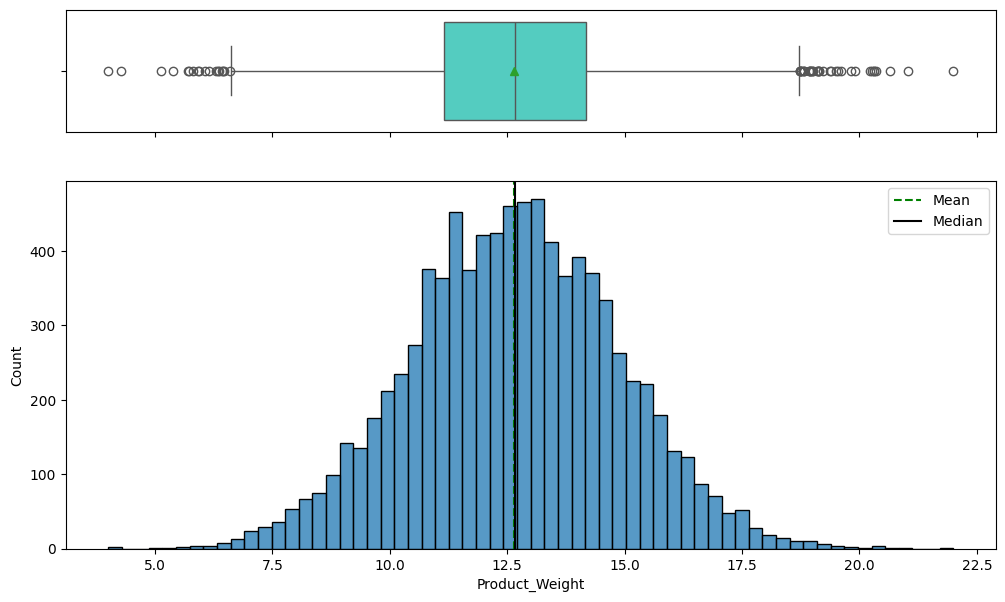

In [22]:
histogram_boxplot(data, "Product_Weight")

**Observation**

- As previously observed, the distribution of product weights is largely symmetrical, with a mean of approximately 12.65 units and a median of 12.66 units, ranging from 4 to 22 units.
- Outliers are visible in the distribution, as shown in the boxplot.

**4.1.3 - Product_Allocated_Area**

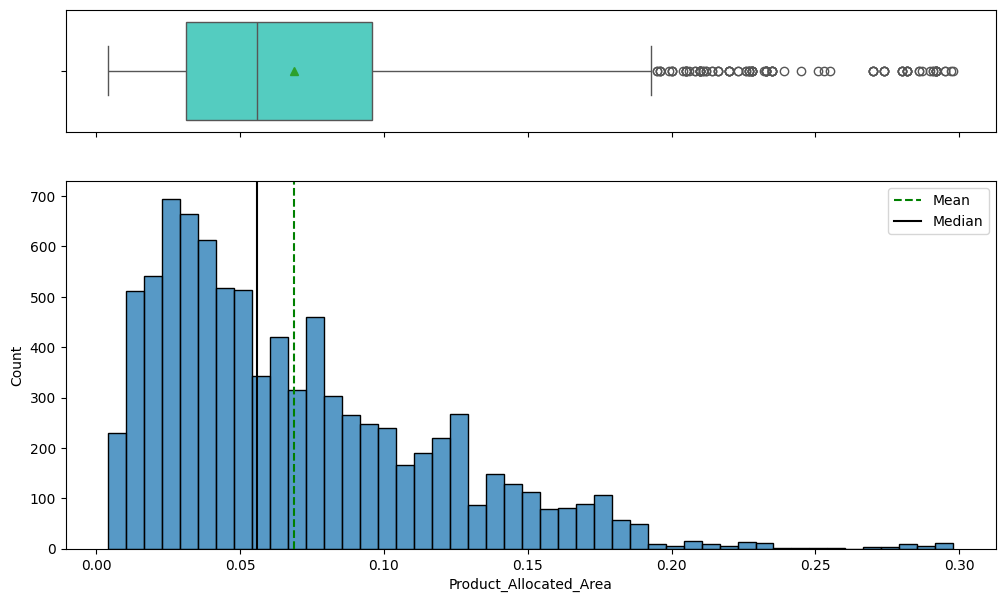

In [23]:
histogram_boxplot(data, "Product_Allocated_Area")

**Observation**

- As previously observed, the allocated display area for products exhibits a right-skewed distribution, suggesting a concentration of smaller areas with a tail extending to larger values.
- Outliers are visible on the right skew, as shown in the boxplot.

**4.1.4 - Product_MRP**

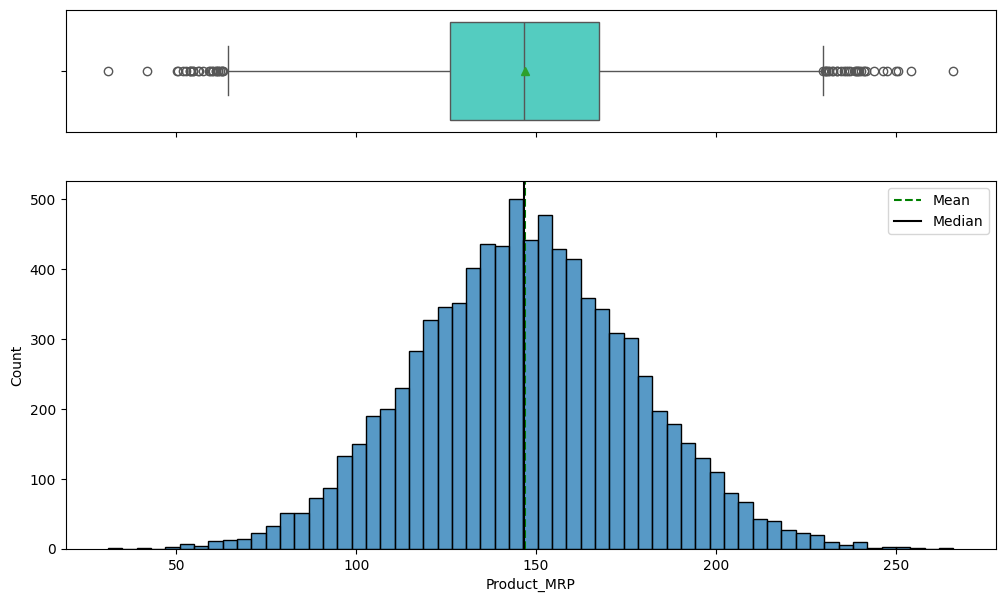

In [24]:
histogram_boxplot(data, "Product_MRP")

**Observation**

- Product prices display a distribution that is nearly symmetrical.
- Outliers are visible in the distribution.

**4.1.5 - Store_Establishment_Year**

In [25]:
print(data["Store_Establishment_Year"].unique())
display(data["Store_Establishment_Year"].describe().T)

[2009 1999 1987 1998]


,Store_Establishment_Year
count,8763.000000
mean,2002.032751
std,8.388381
min,1987.000000
25%,1998.000000
50%,2009.000000
75%,2009.000000
max,2009.000000


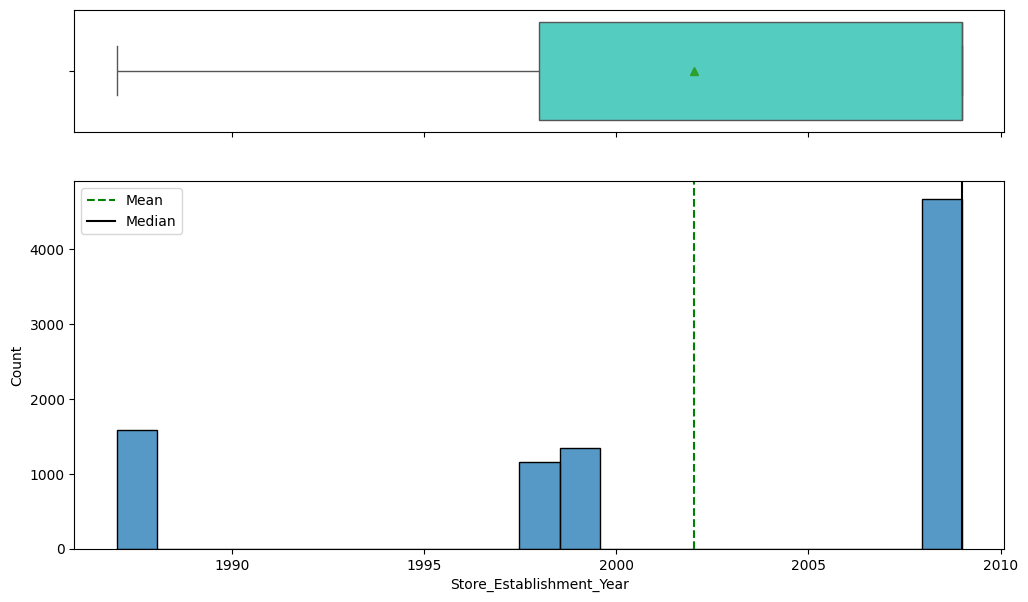

In [26]:
histogram_boxplot(data, "Store_Establishment_Year")

**Observation**

- As observed earlier distribution shows higher frequency of more recently established stores.
- There are only 4 unique values in this feature, 2009 1999 1998 1987.

**4.1.6 - Product_Store_Sales_Total**

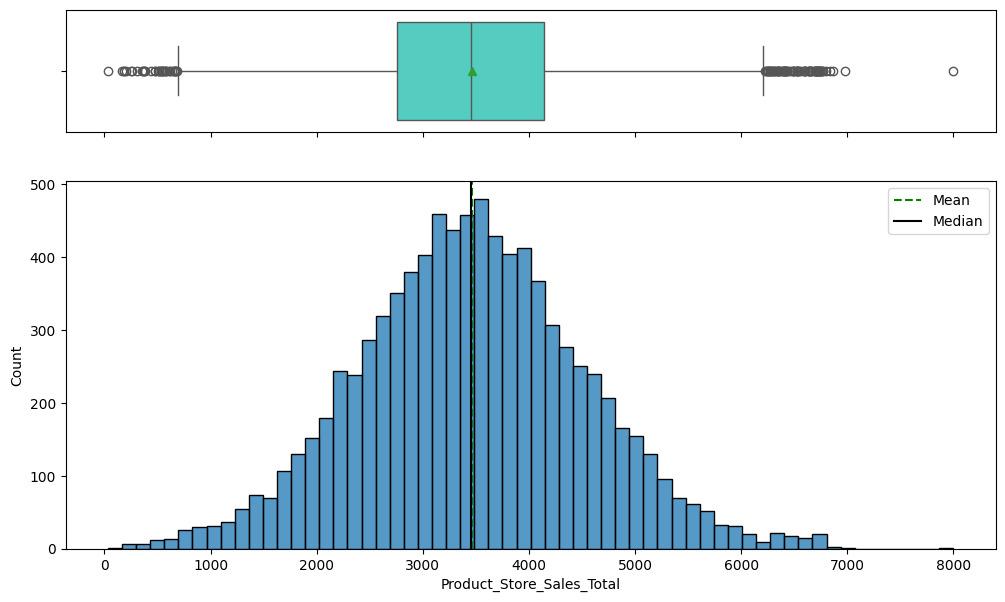

In [27]:
histogram_boxplot(data, "Product_Store_Sales_Total")

**Observation**

- Outliers are visible in the distribution.

**4.1.7 - Product_Sugar_Content**

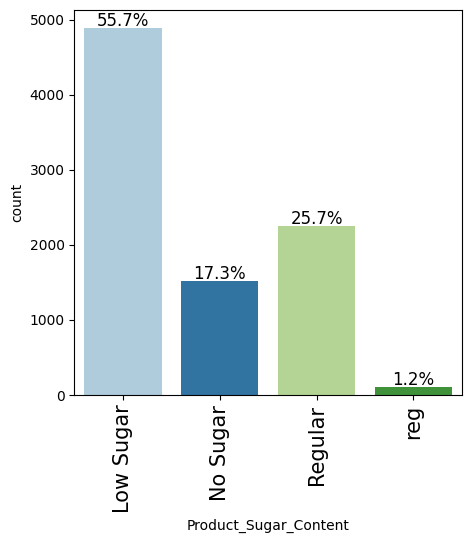

In [28]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

**Observation**

- Low Sugar products dominate (55.7%), followed by Regular (25.7%) and No Sugar (17.3%).
- A small share (1.2%) is labeled as "reg", likely a variant of Regular. "reg" and "Regular" class can be combined

**4.1.8 - Product_Type**

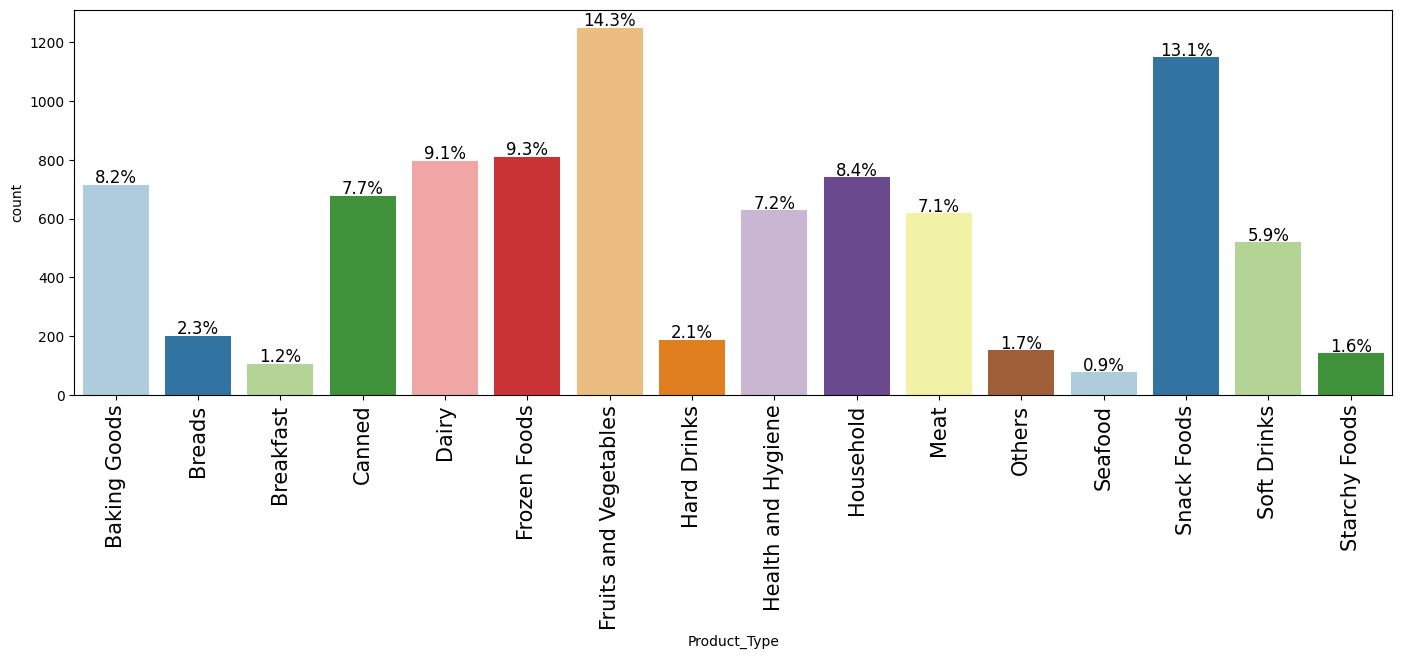

In [29]:
labeled_barplot(data, "Product_Type", perc=True)

**Observation**

- **Fruits and Vegetables** followed by **Snack Foods**  are the top categories, while Frozen Foods, Dairy, and Household each hold around **8–9%** andSpecialty categories like Seafood, Breakfast, and Starchy Foods have less than **2%** share.

**4.1.9 - Store_Id**

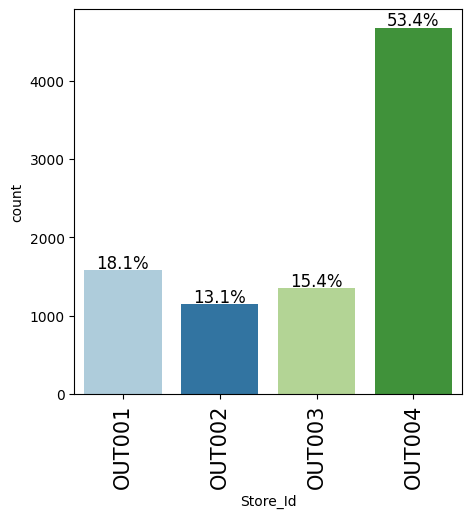

In [30]:
labeled_barplot(data, "Store_Id", perc=True)

**4.1.10 - Store_Type**

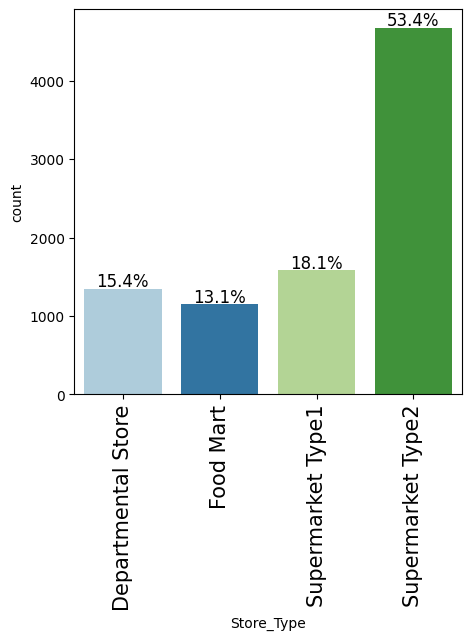

In [31]:
labeled_barplot(data, "Store_Type", perc=True)

**Observation**

- The Store_Id and Store_Type columns show similar distributions and top frequencies, suggesting a strong correlation or direct mapping between particular store IDs and their types.
- The Store_Id 'OUT004' and Store_Type 'Supermarket Type2' both occur with the same frequency of 53.4%.

**4.1.11 - Store_Size**

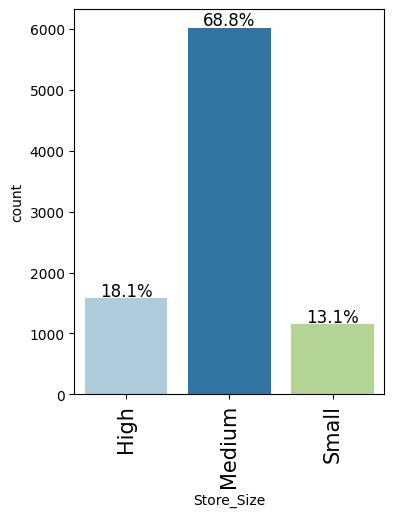

In [32]:
labeled_barplot(data, "Store_Size", perc=True)

**Observation**

- Medium-sized stores generated more sales

**4.1.12 - Store_Location_City_Type**

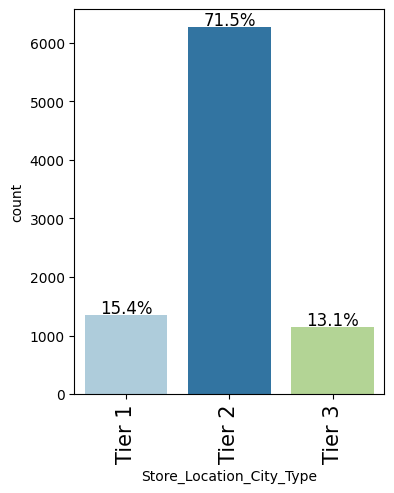

In [33]:
labeled_barplot(data, "Store_Location_City_Type", perc=True)

**Observation**

- More products are sold in stores that are located in Tier 2 cities.

## **4.2 Bivariate Analysis**

Given that Product_Store_Sales_Total is our numerical dependent variable, the subsequent code cells will perform bivariate analysis to investigate its correlations and relationships with the independent feature variables.

**4.2.1 - Correlation Analysis of Numerical Features and Target Variable**

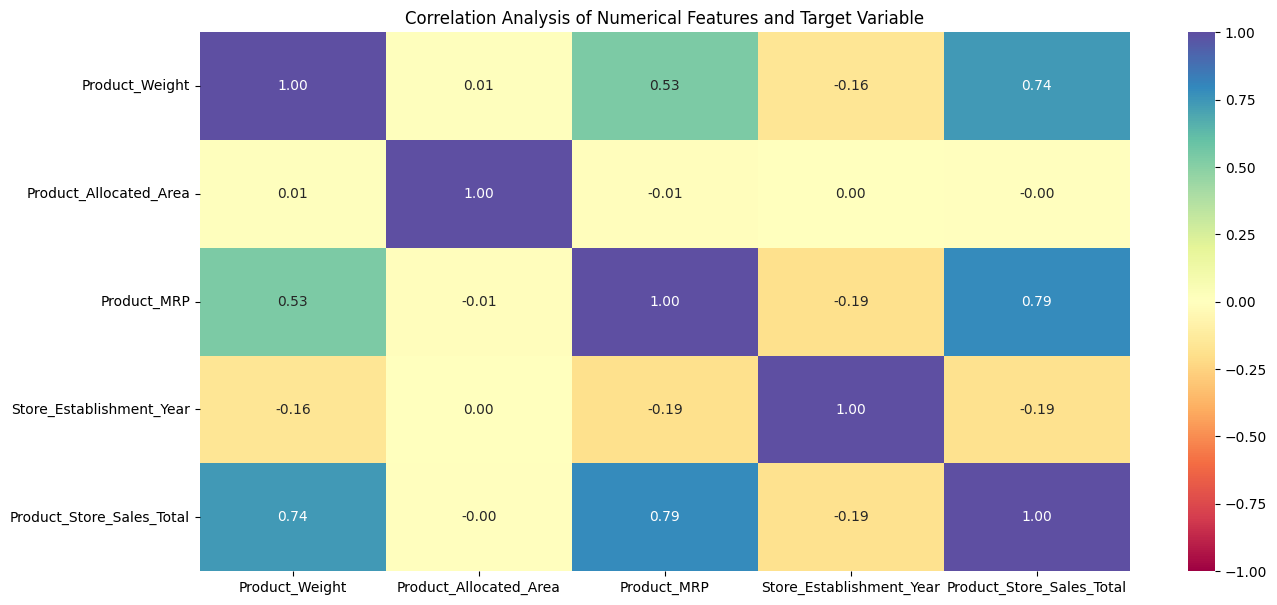

In [34]:
# Plot the correlation between numerical columns
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.title("Correlation Analysis of Numerical Features and Target Variable")
plt.show()

**Observation**

- Numerical columns with positive correlation to 'Product_Sales_Total':

             ['Product_MRP', 'Product_Weight']

- Numerical columns with negative correlation to 'Product_Sales_Total':

             ['Store_Establishment_Year', 'Product_Allocated_Area']

-**Positive Correlation**

- Product_Weight has a strong positive correlation with Product_Store_Sales_Total
- Product_MRP has a strong positive correlation with Product_Store_Sales_Total
- Product_MRP and Product_Weight have a strong positive corrleation with each other

-**Negative Correlation**
- Product_Weight and Store_Establishment_Year have a very weak negative coorelation with each other
- Product_MRP and Store_Establishment_Year have a very weak negative - coorelation with each other
- Product_Sales_Total and Store_Establishment_Year have a very weak negative coorelation with each other
- Product_Allocated_Area and Store_Etablishment_Year both have a weak negative correlation with Product Sales Total

-**No Correlation**

- Product_Allocated_Area has no correlation with any other variables in the dataset.

Based on these notes so far the Product_Weight and Product_MRP as far as the numerical values are concerned have the strongest influece on Product_Store_Sales_Total. So we definitely want to include these values as part of our linear regression model. Product_Allocated_Area can be potentially dropped since it has no correlation at all with any of the other variables but most importantly no correlation with Product_Store_Sales_Total which is our target variable.

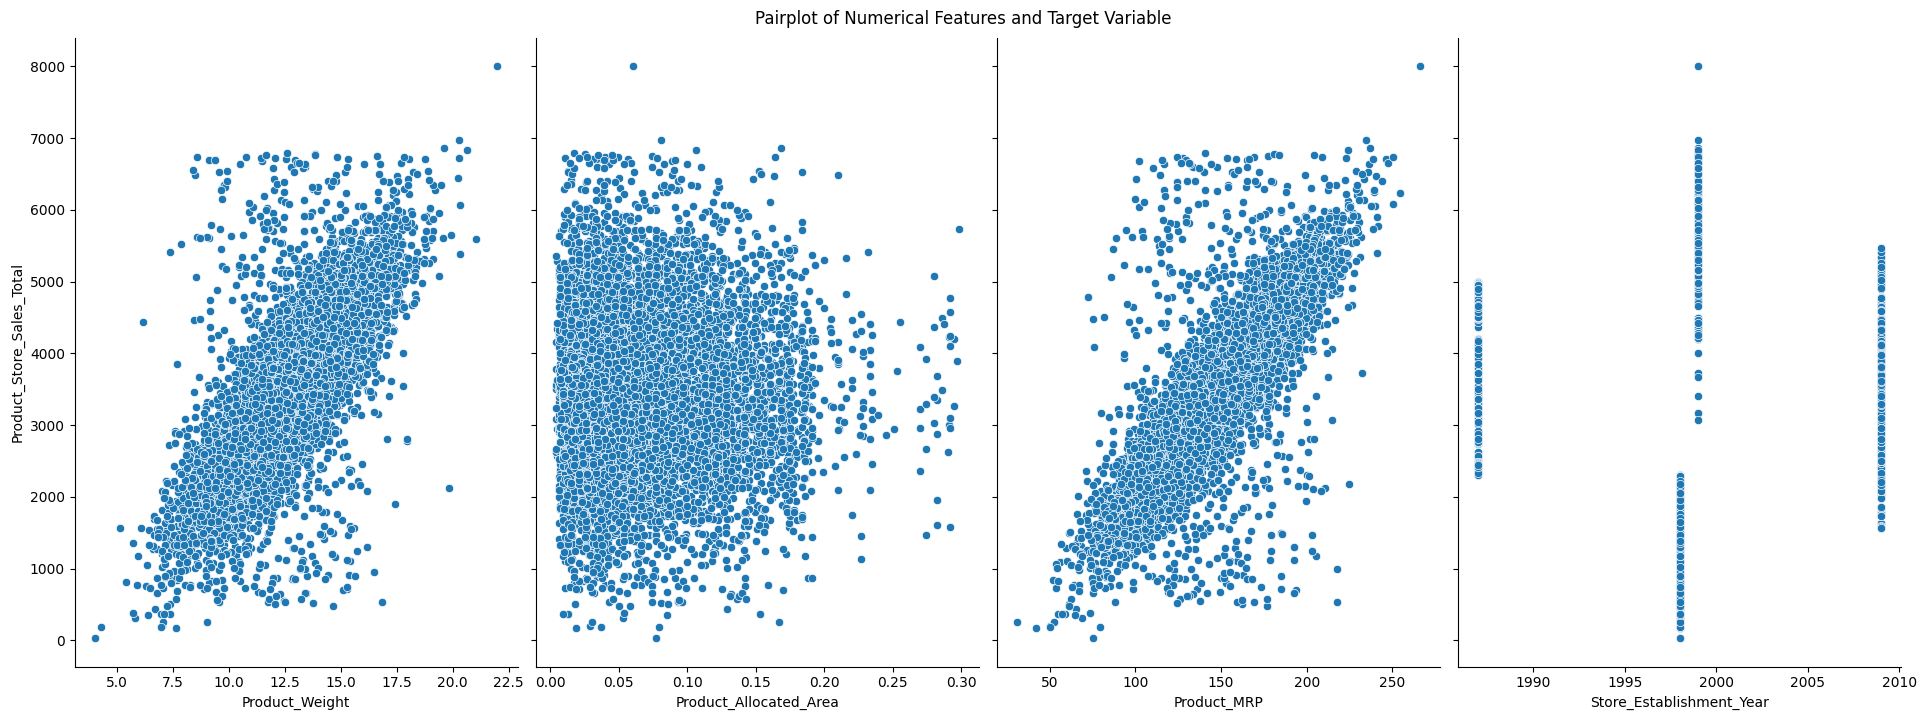

In [35]:
g = sns.pairplot(
    data,
    x_vars=["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Establishment_Year"],
    y_vars=["Product_Store_Sales_Total"],
    height=7,
    aspect=0.7,
)
g.fig.suptitle("Pairplot of Numerical Features and Target Variable", y=1.02)
plt.show()

**Observation**

- There is a positive correlation between Product_Store_Sales_Total and Product_Weight (0.74), as well as with Product_MRP.

**4.2.2 - Revenue Analysis by Categorical Features**

In [36]:
def plot_sales_by_category(dataframe, category_feature):
    """
    Groups the DataFrame by a specified categorical feature, calculates the sum of
    'Product_Store_Sales_Total', and plots the results as a bar chart.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        category_feature (str): The name of the categorical column to group by.
    """
    df_revenue = dataframe.groupby([category_feature], as_index=False)[
        "Product_Store_Sales_Total"
    ].sum()
    # Sort the DataFrame by Product_Store_Sales_Total in descending order
    df_revenue = df_revenue.sort_values(by="Product_Store_Sales_Total", ascending=False)
    display(df_revenue)

    plt.figure(figsize=[8, 6])
    plt.xticks(rotation=90)
    sns.barplot(x=df_revenue[category_feature], y=df_revenue.Product_Store_Sales_Total, order=df_revenue[category_feature])
    plt.xlabel(category_feature.replace('_', ' '))
    plt.ylabel("Revenue")
    plt.title(f"Revenue by {category_feature.replace('_', ' ')}")
    plt.show()

**4.2.2.1 - Revenue analysis by Product_Type**

,Product_Type,Product_Store_Sales_Total
6,Fruits and Vegetables,4300833.27
13,Snack Foods,3988996.95
4,Dairy,2811918.04
5,Frozen Foods,2809980.83
9,Household,2564740.17
0,Baking Goods,2452986.00
3,Canned,2300082.71
8,Health and Hygiene,2163707.21
10,Meat,2129211.94
14,Soft Drinks,1797044.72


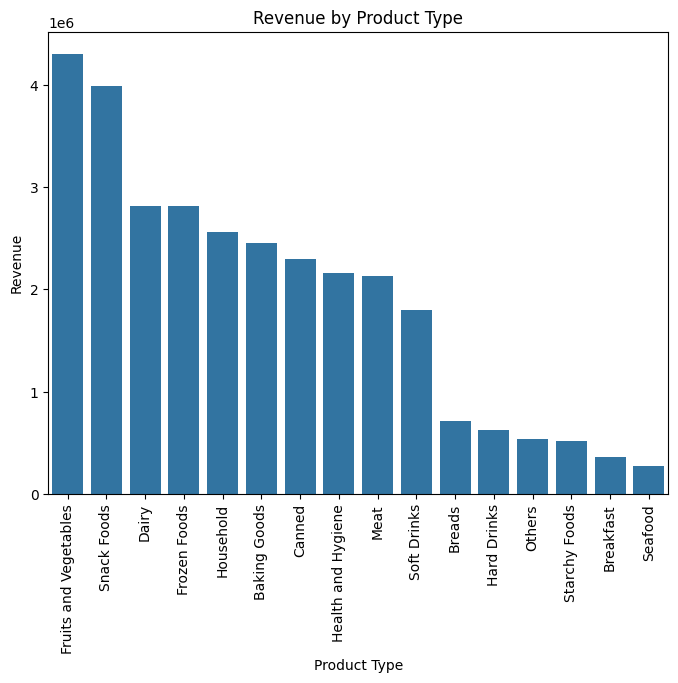

In [37]:
# Using the function for 'Product_Type'
plot_sales_by_category(data, "Product_Type")

### **Observation**

- "Fruits and Vegetables" and "Snack Foods" generated more revenue.

## **4.2.2.2 - Revenue analysis by Product_Sugar_Content**

,Product_Sugar_Content,Product_Store_Sales_Total
0,Low Sugar,16823405.80
2,Regular,7867671.29
1,No Sugar,5269943.68
3,reg,394043.13


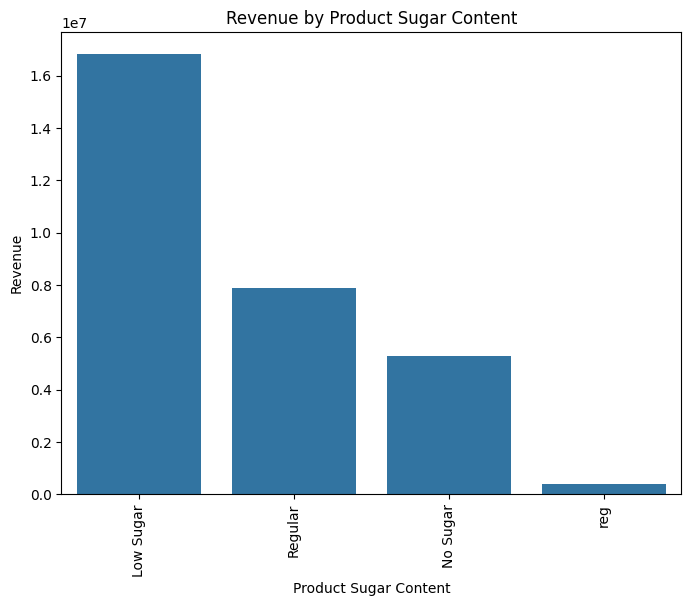

In [38]:
# Using the function for 'Product_Sugar_Content'
plot_sales_by_category(data, "Product_Sugar_Content")

**Observation**

- "Low Sugar" products generated more revenue.

### **4.2.2.3 - Revenue analysis by Store_Id**

,Store_Id,Product_Store_Sales_Total
3,OUT004,15427583.43
2,OUT003,6673457.57
0,OUT001,6223113.18
1,OUT002,2030909.72


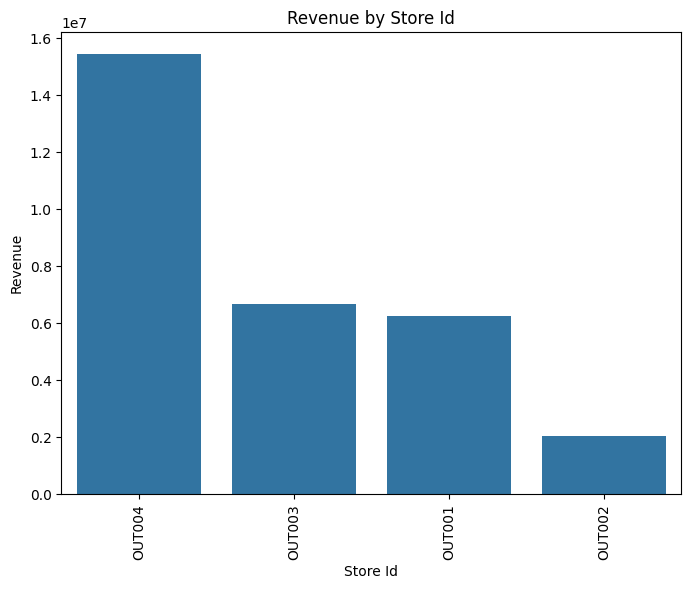

In [39]:
plot_sales_by_category(data, "Store_Id")

**Observation**

- Store Id of "OUT004" has generated more revenue and "OUT002" the least revenue.

## **4.2.2.4 - Revenue analysis by Store_Type**

,Store_Type,Product_Store_Sales_Total
3,Supermarket Type2,15427583.43
0,Departmental Store,6673457.57
2,Supermarket Type1,6223113.18
1,Food Mart,2030909.72


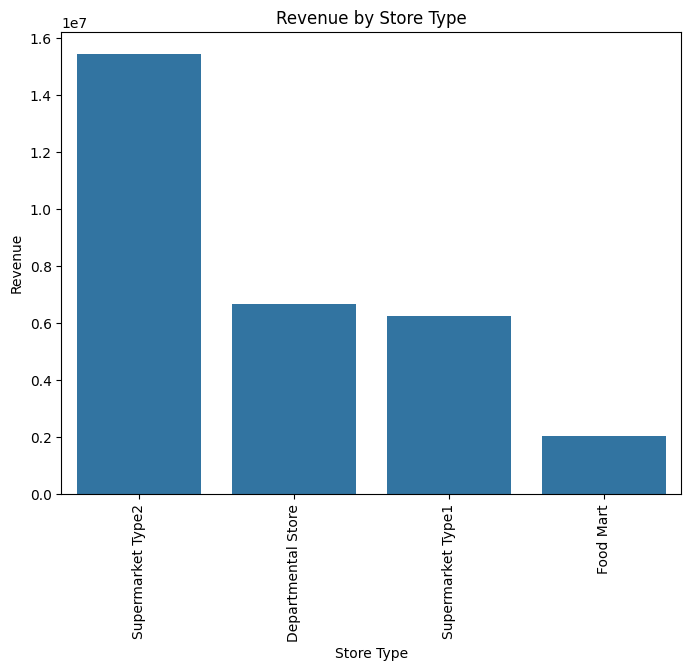

In [40]:
plot_sales_by_category(data, "Store_Type")

**Observation**

- "Supermarket Type2" stores has generated more revenue.
- It is already established that Store_Id and Store_Type are highly correlated.

**4.2.2.5 - Revenue analysis by Store_Size**

,Store_Size,Product_Store_Sales_Total
1,Medium,22101041.00
0,High,6223113.18
2,Small,2030909.72


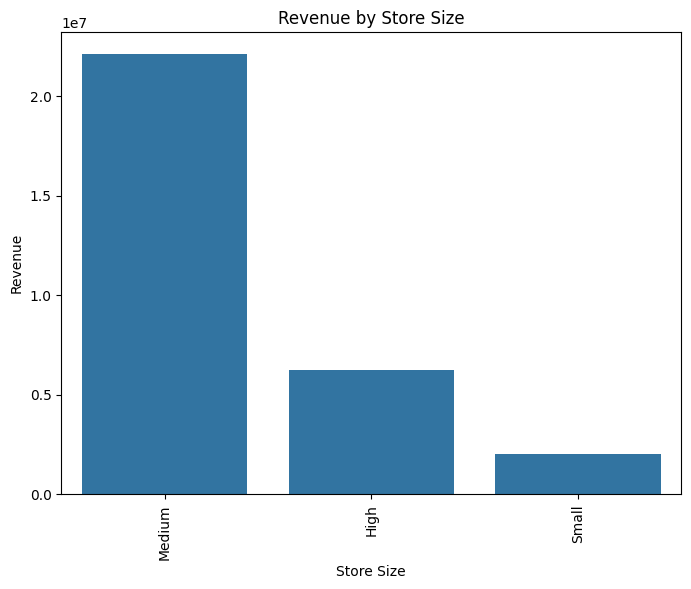

In [41]:
plot_sales_by_category(data, "Store_Size")

**Observation**

"Medium" size stores have generated high revenue.

**4.2.2.6 - Revenue analysis by Store_Location_City_Type**

,Store_Location_City_Type,Product_Store_Sales_Total
1,Tier 2,21650696.61
0,Tier 1,6673457.57
2,Tier 3,2030909.72


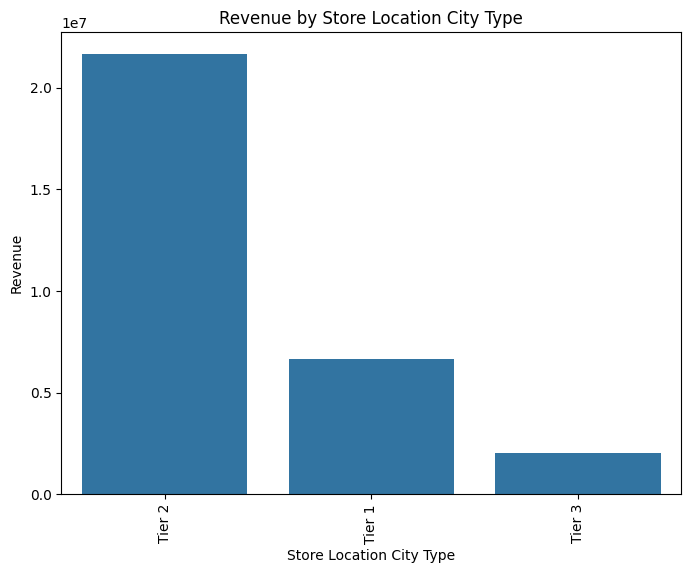

In [42]:
plot_sales_by_category(data, "Store_Location_City_Type")

**Observations**

Top Revenue generators within the Categorical Features

- **Product Type**: **'Fruits and Vegetables'** generated the highest revenue among all product types.
- **Product Sugar Content**: Products with **'Low Sugar'** content contributed the most to the total revenue, aligning with their higher sales volume.
- **Store Performance**: Store **'OUT004'**, identified as a **'Supermarket Type 2'**, recorded the highest revenue compared to other store IDs and types.
- **Store Size**: **Medium-sized stores** were the highest revenue generators.
- **Store Location**: Stores located in **Tier 2 cities** produced the most revenue.

## **4.2.3 - Per Product Sales Distribution by Categorical Features**

### **4.2.3.1 - Store_Id vs Product_Store_Sales_Total**

In [43]:
def plot_sales_boxplot_by_category(dataframe, category_feature, y_feature="Product_Store_Sales_Total"):
    """
    Generates a box plot showing the distribution of sales for each category
    of a specified categorical feature.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        category_feature (str): The name of the categorical column to plot on the x-axis and as hue.
        y_feature (str): The name of the numerical column for the y-axis (default is 'Product_Store_Sales_Total').
    """
    plt.figure(figsize=[14, 8])
    sns.boxplot(data=dataframe, x=category_feature, y=y_feature, hue=category_feature)
    plt.xticks(rotation=90)
    plt.title(f"Boxplot - {category_feature} Vs {y_feature}")
    plt.xlabel(category_feature)
    plt.ylabel(f"{y_feature} (of each product)")
    plt.show()

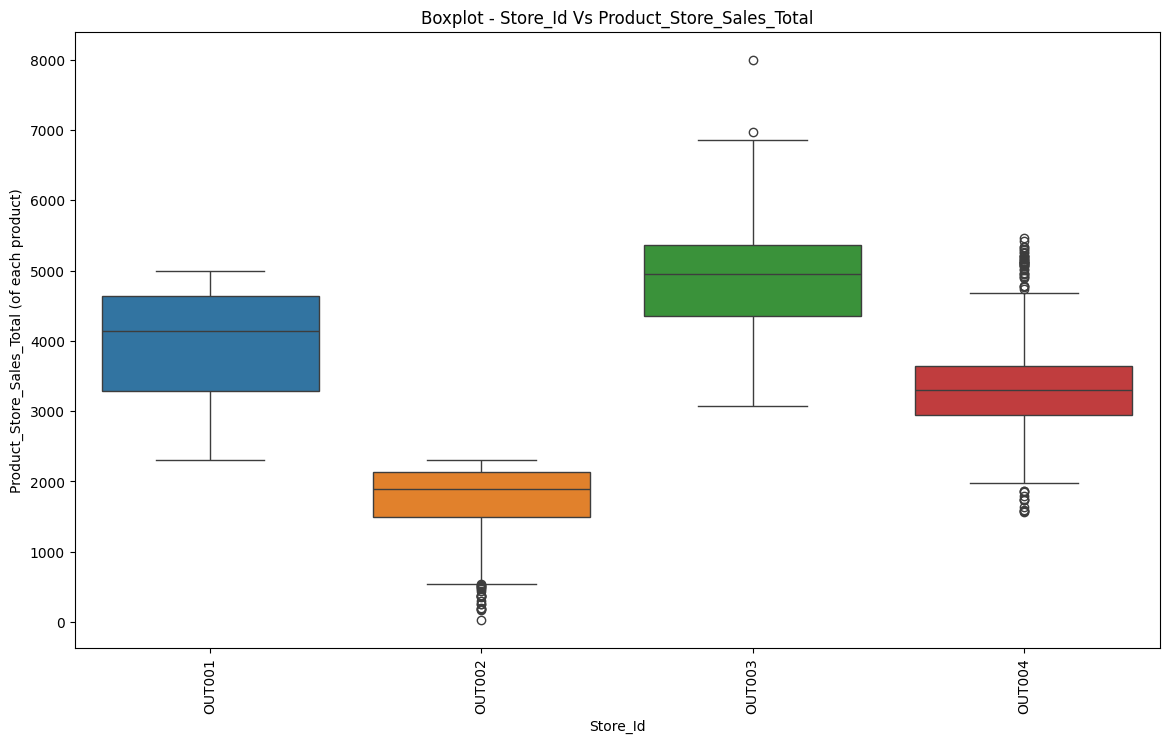

In [44]:
plot_sales_boxplot_by_category(data, "Store_Id")

**Observation**

- Store OUT003 exhibits the highest median sales **per product**, along with the widest range, including some of the highest individual sales (outliers).
- Store OUT001 shows a good range of sales, with a median higher than OUT002 and OUT004.
- Store OUT004 has a more concentrated distribution of sales, with a median lower than OUT001 and OUT003, but still outperforms OUT002.
- Store OUT002 consistently displays the lowest median sales and the narrowest sales range, indicating generally lower sales performance per product.

**4.2.3.2 - Store_Size vs Product_Store_Sales_Total**

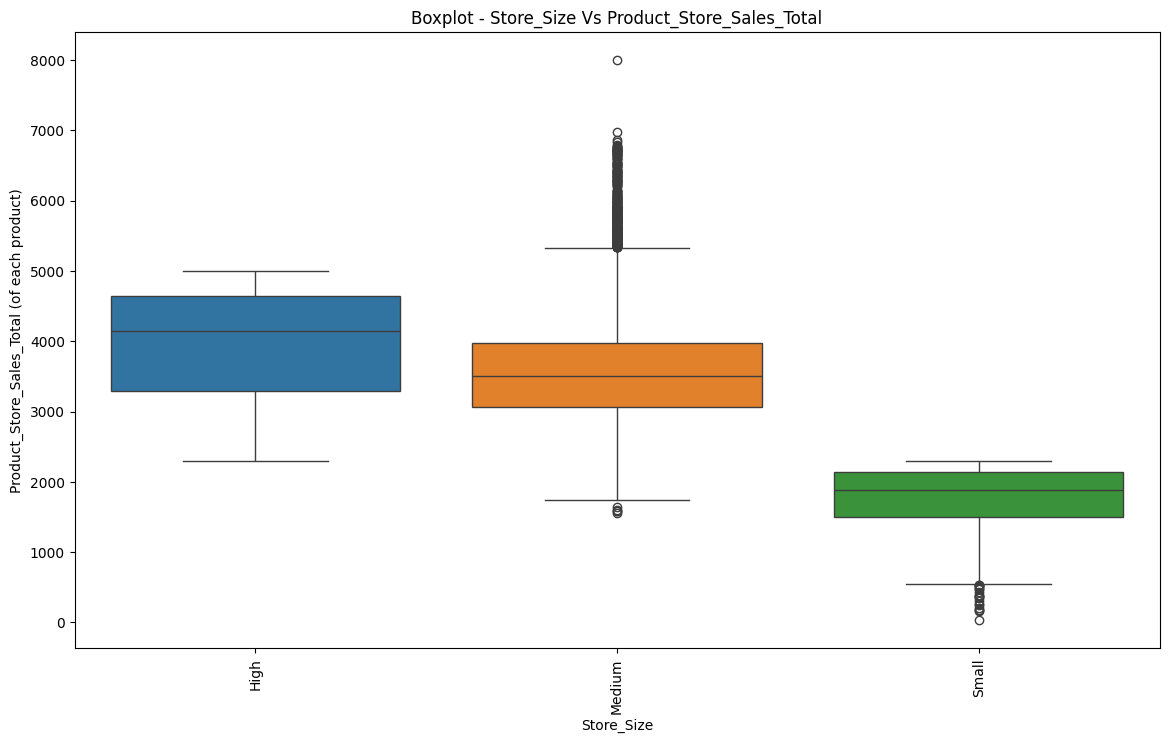

In [45]:
plot_sales_boxplot_by_category(data, "Store_Size")

**Observation**

- Small-sized stores consistently have the lowest median sales per product and the least variability, indicating generally lower individual product sales.
- High-sized stores have a highest median sales per product and a wider interquartile range, suggesting some products perform very well while others are average.
- Medium-sized stores generated more sales. They also exhibit a wider spread in sales, indicating a more diverse range of product sales performance.

**4.2.3.3 - Product_Type vs Product_Store_Sales_Total**

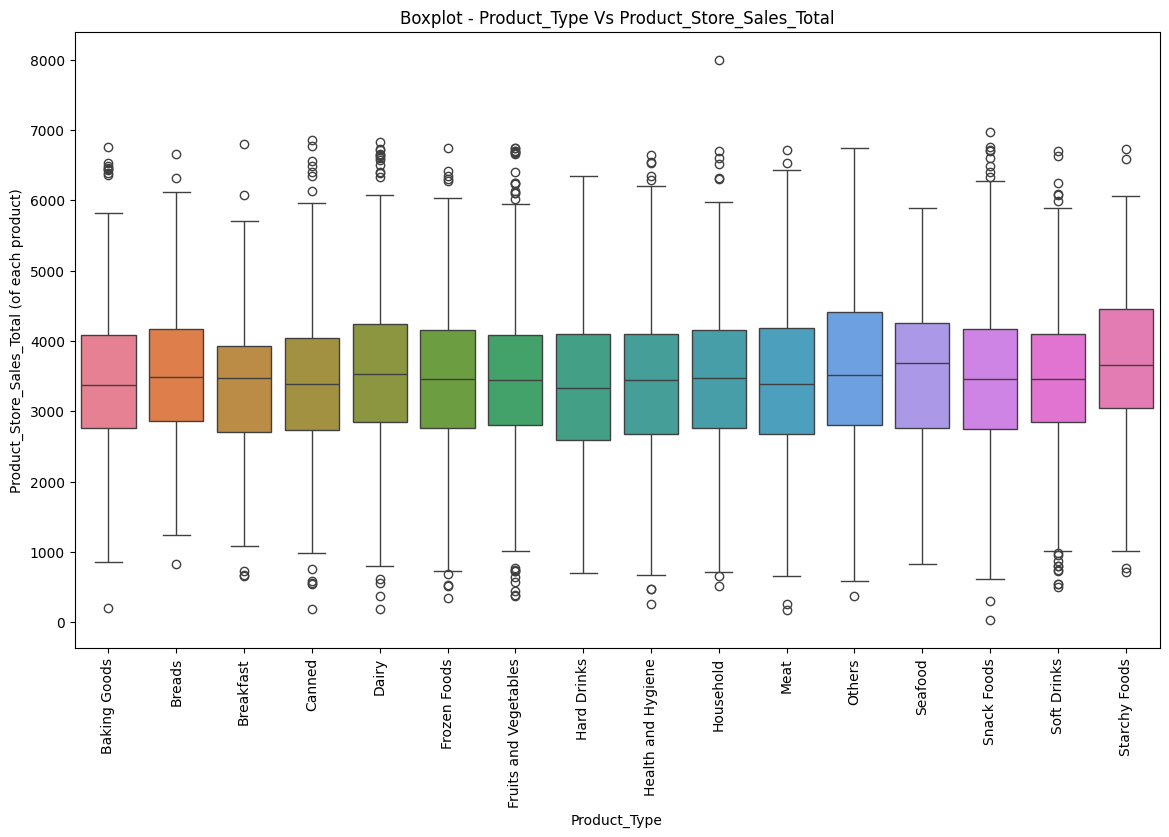

In [46]:
plot_sales_boxplot_by_category(data, "Product_Type")

**Observation**

Most product types show similar median sales per product and many types having outliers.

**4.2.3.4 - Product_Sugar_Content vs Product_Store_Sales_Total**

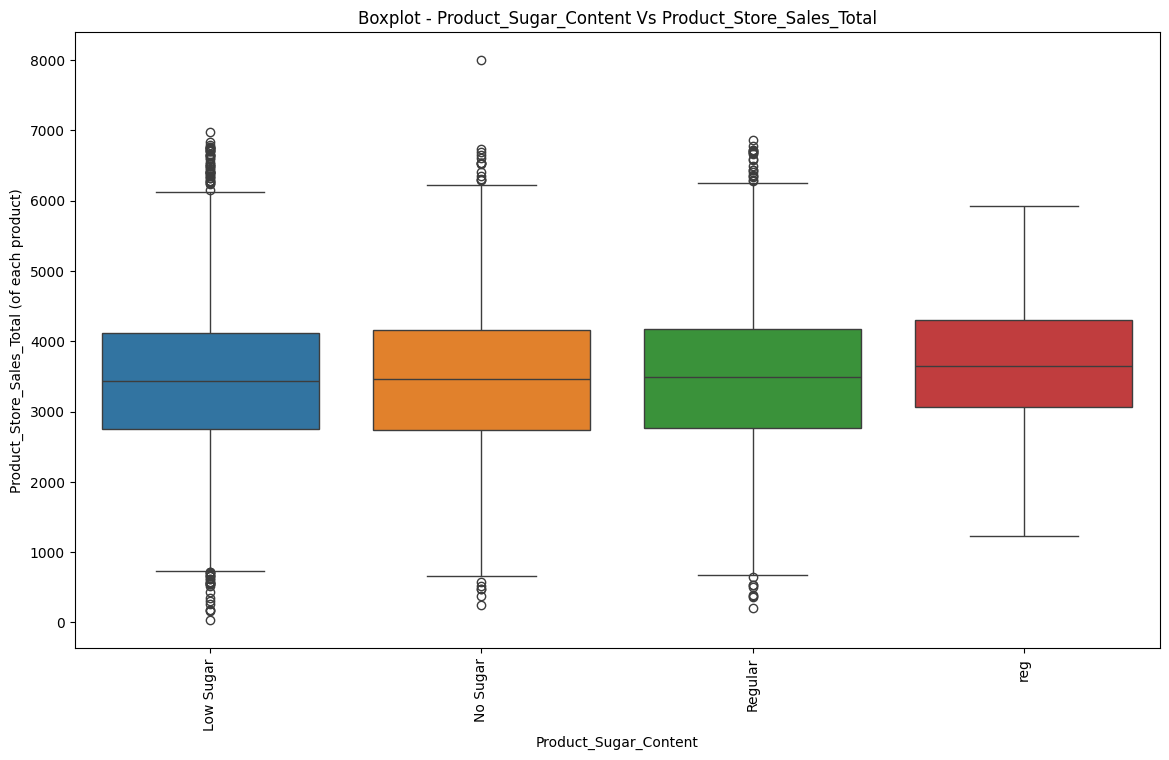

In [47]:
plot_sales_boxplot_by_category(data, "Product_Sugar_Content")

**Observation**

- The median sales per product are comparable across different Product_Sugar_Content categories. However, 'Low Sugar' and 'Regular' products exhibit a wider distribution of sales and a higher number of outliers with higher sales values, indicating more variability and potential for higher individual product sales compared to 'No Sugar' products.

**4.2.3.5 - Store_Location_City_Type vs Product_Store_Sales_Total**

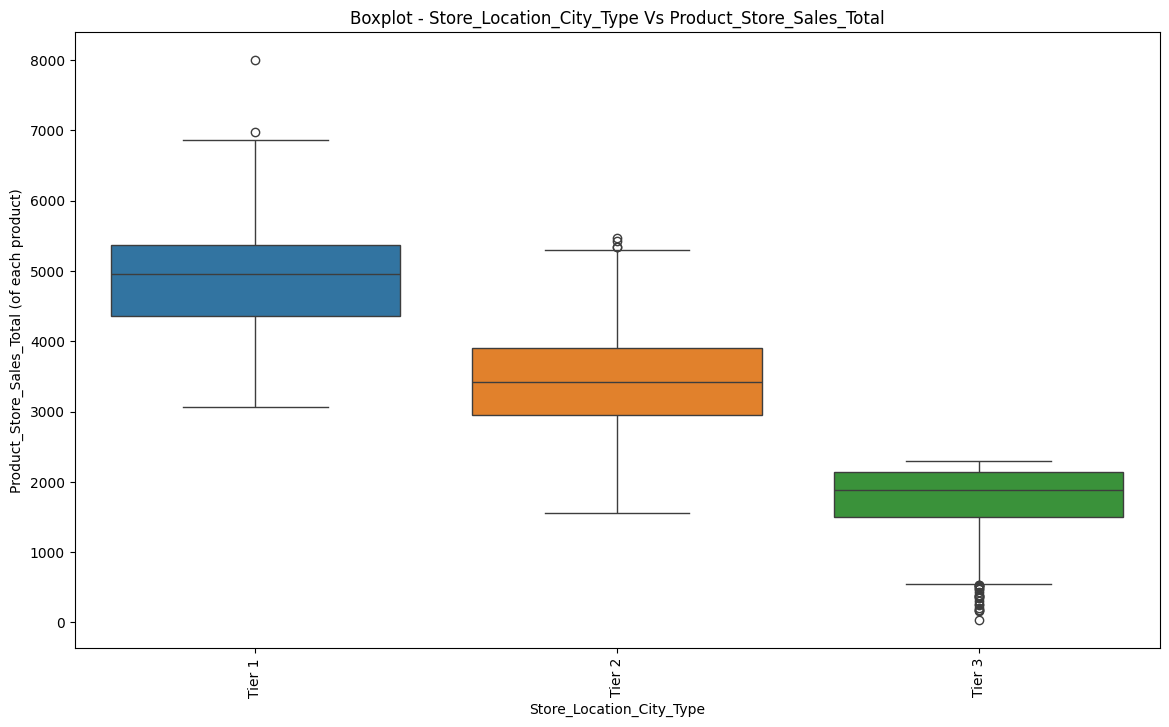

In [48]:
plot_sales_boxplot_by_category(data, "Store_Location_City_Type")

**Observation**

- Stores located in Tier 3 cities exhibit the lowest median sales per product and a relatively compact interquartile range, indicating less variability in sales compared to stores in Tier 1 and Tier 2 cities.





# **4.2.4 - Further Bivariate Analysis of Inter-feature Relationships'**

**4.2.4.1 - Product_Type vs Product-Weight**

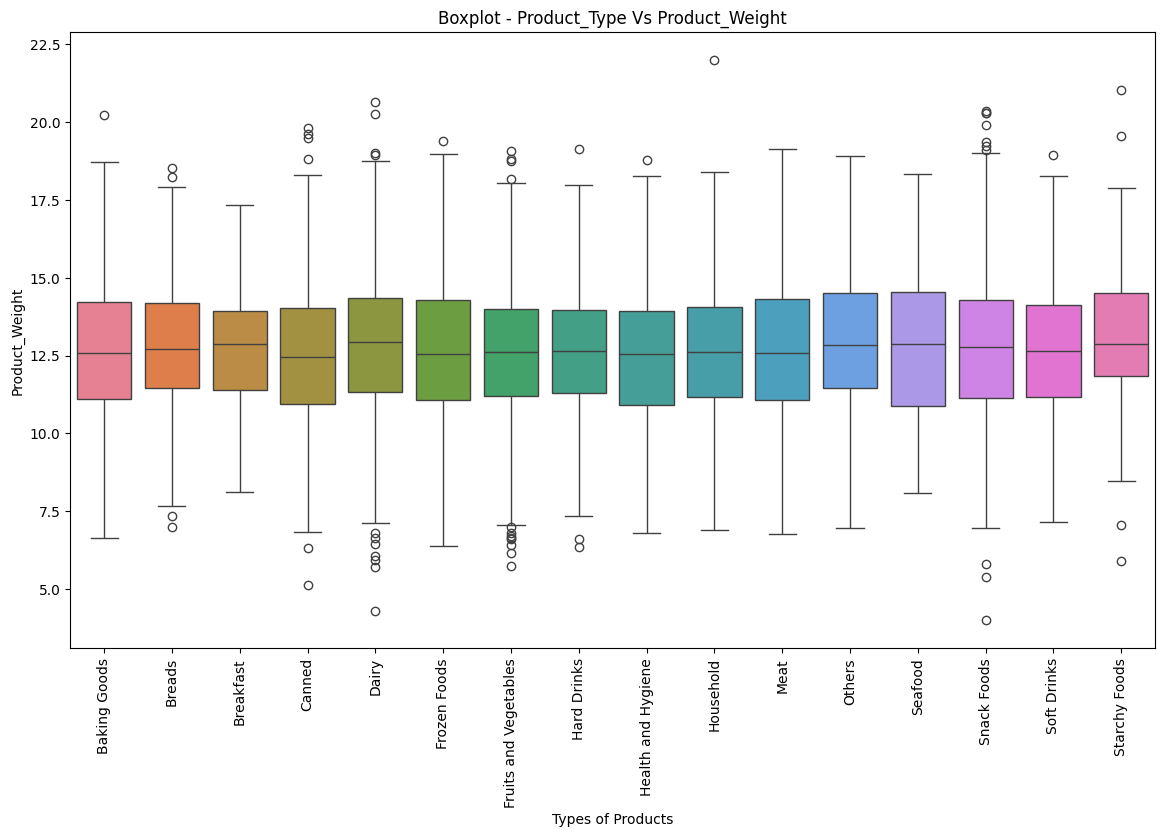

In [49]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_Weight", hue = "Product_Type")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")
plt.show()

**Observation**

- As previously noted, Product_Weight has a positive correlation with Product_Store_Sales_Total.
- From this plot, we can see that the Product_Weight distribution is relatively consistent across most Product_Type categories, with their median weights generally clustering around a similar range.
- However, several product types exhibit outliers, indicating that some individual products within these categories have weights significantly outside the typical range for their respective types.

**4.2.4.2 - Product_Sugar_Content vs Product_Weight**

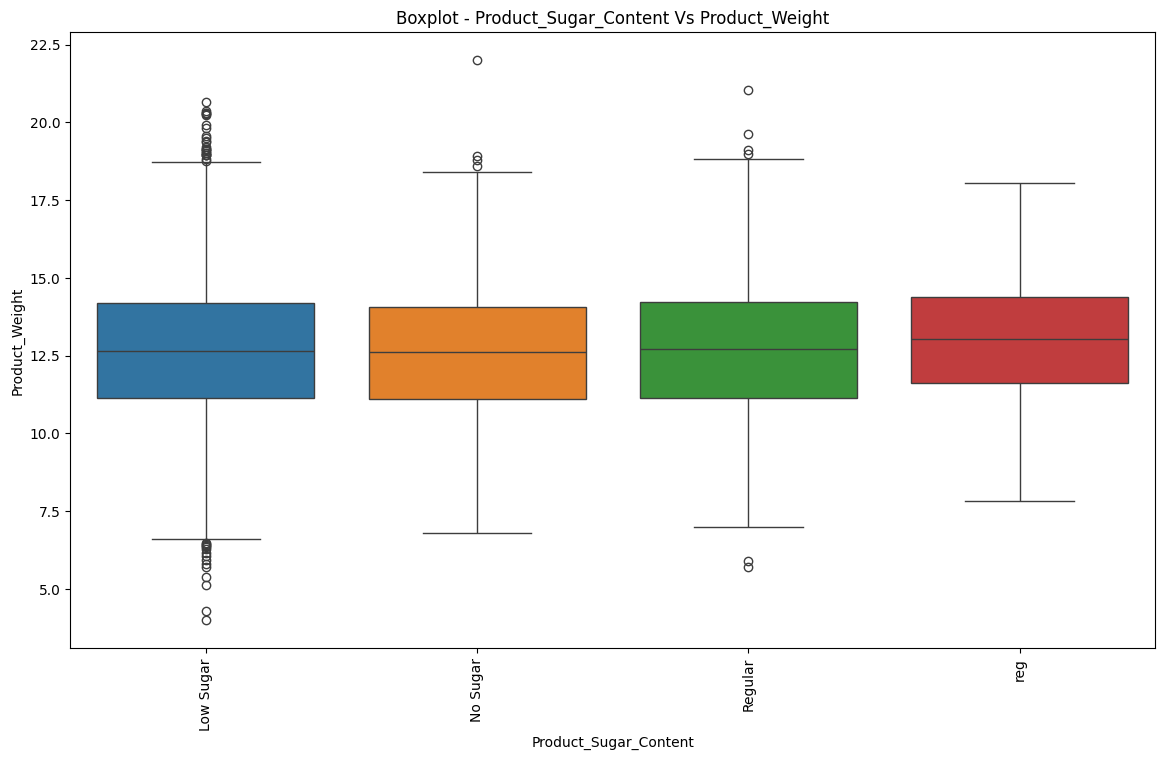

In [50]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Sugar_Content", y = "Product_Weight", hue = "Product_Sugar_Content")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Sugar_Content Vs Product_Weight")
plt.xlabel("Product_Sugar_Content")
plt.ylabel("Product_Weight")
plt.show()

**Observation**

- Product_Weight distribution is consistent across different Product_Sugar_Content levels.

**4.2.4.3 - Product_Type vs Product_MRP**

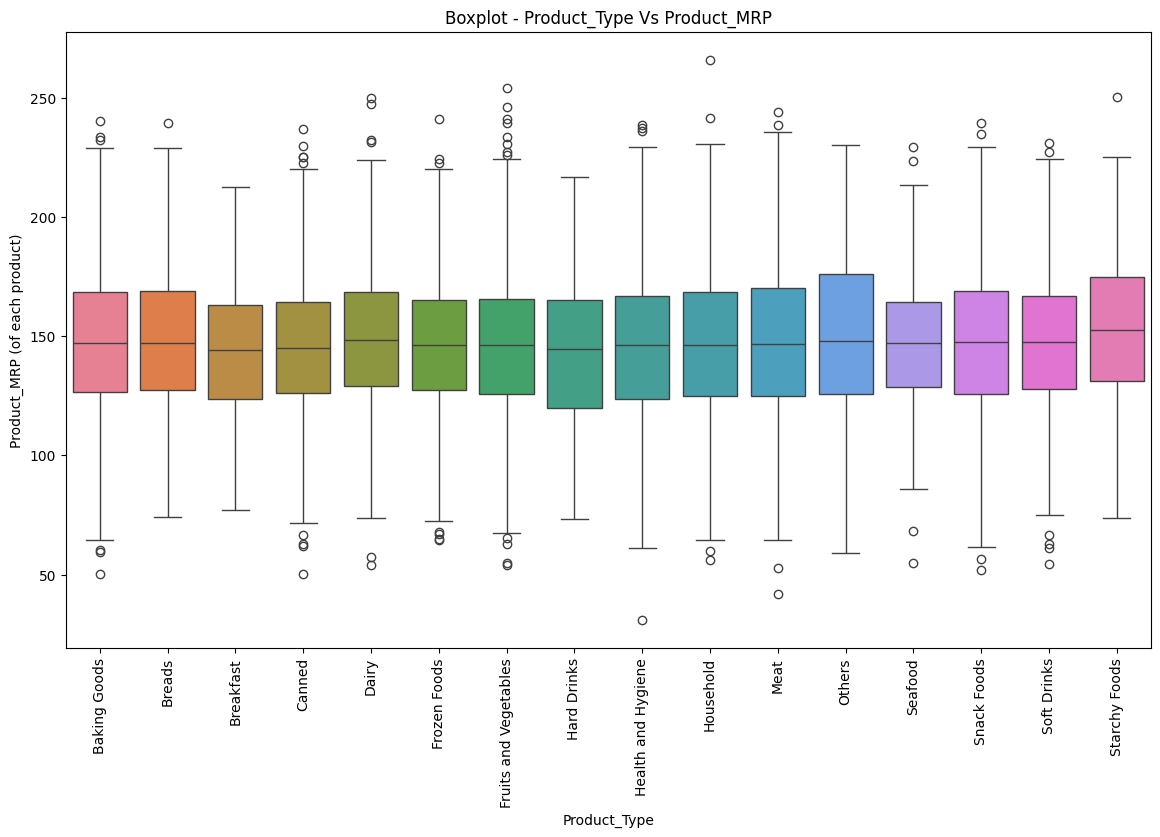

In [51]:
plot_sales_boxplot_by_category(data, category_feature="Product_Type", y_feature="Product_MRP")

**Observation**

- The median MRP for most product types is remarkably similar, hovering around the 140 to 150 range. This suggests a uniform pricing strategy across different grocery segments.
- Fruits and Vegetables and Dairy show a significant number of high-priced outliers

**4.2.4.4 - Store_Id vs Product_MRP**

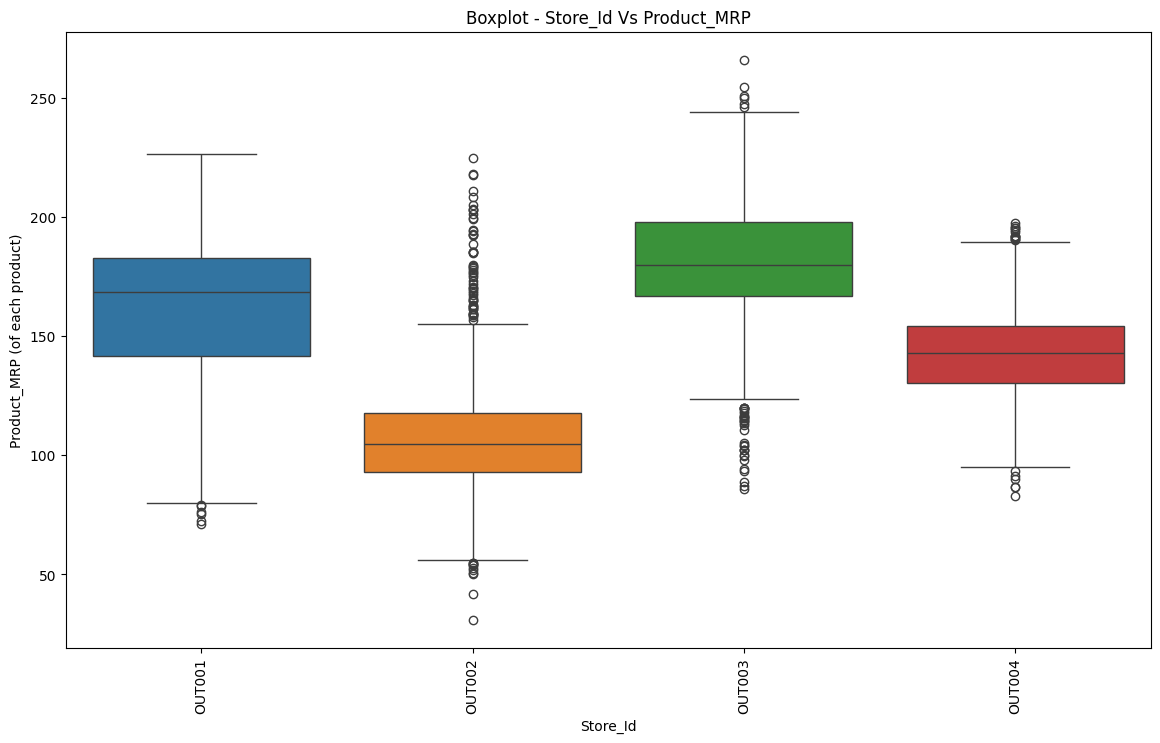

In [52]:
plot_sales_boxplot_by_category(data, category_feature="Store_Id", y_feature="Product_MRP")

**Observation**

- While outliers for Product_MRP are visible across all Store_Ids, indicating some products with exceptionally high or low prices, Store 'OUT003' stands out for having sold products with the highest MRP.

# **5 - Data Preprocessing**

**5.1 - Preprocess Product_Sugar_Content**

As seen earlier, Product_Sugar_Content column conatins 4 types - "Low Sugar", "Regular", "No Sugar", "reg" with 'reg' and 'Regular' likely represening the same sugar content level, we would Replace "reg" with "Regular"

In [53]:
# Replace reg with Regular
data["Product_Sugar_Content"].replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [54]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


**5.2 - Store's Age**

- The Store_Establishment_Year column contains four unique values: 1987, 1999, 1998, and 2009.
- The dataset shows a higher frequency of more recently established stores.
- To incorporate the potential influence of a store's age on sales for modeling, we will calculate the Store_Age_Years."

In [55]:
# Store Age
data["Store_Age_Years"] = 2026 - data.Store_Establishment_Year

In [56]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28


**5.3 - Feature Binning: Product_Type**

- There are 16 different product types in our dataset.
- To reduce dimensionality and potentially capture broader patterns, we will perform feature binning by grouping these types into two main categories: Perishables and Non-Perishables.

In [57]:
data["Product_Type"].unique().tolist()

['Frozen Foods',
 'Dairy',
 'Canned',
 'Baking Goods',
 'Health and Hygiene',
 'Snack Foods',
 'Meat',
 'Household',
 'Hard Drinks',
 'Fruits and Vegetables',
 'Breads',
 'Soft Drinks',
 'Breakfast',
 'Others',
 'Starchy Foods',
 'Seafood']

In [58]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [59]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [60]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [61]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28,Non Perishables


**5.4 - Extracting Two Letter Pattern from Product_ID**

In [62]:
data["Product_Id"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8763 entries, 0 to 8762
Series name: Product_Id
Non-Null Count  Dtype   
--------------  -----   
8763 non-null   category
dtypes: category(1)
memory usage: 343.7 KB


In [63]:
# Extract the first two characters from the Product_Id column and store it in a new column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27,Perishables,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28,Non Perishables,NC


In [64]:
data["Product_Id_char"].value_counts()

,count
Product_Id_char,
FD,6539
NC,1519
DR,705


In [65]:
display(data.loc[data.Product_Id_char == "FD", "Product_Type"].unique())
display(data.loc[data.Product_Id_char == "NC", "Product_Type"].unique())
display(data.loc[data.Product_Id_char == "DR", "Product_Type"].unique())

['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods', ..., 'Fruits and Vegetables', 'Breads', 'Breakfast', 'Starchy Foods', 'Seafood']
Length: 11
Categories (16, object): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods',
                          'Soft Drinks', 'Starchy Foods']

['Health and Hygiene', 'Household', 'Others']
Categories (16, object): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods',
                          'Soft Drinks', 'Starchy Foods']

['Hard Drinks', 'Soft Drinks']
Categories (16, object): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods',
                          'Soft Drinks', 'Starchy Foods']

**Observation**

 - Products with IDs starting with 'DR' appear to be drinks, while those with 'NC' prefixes seem to categorize non-consumable items.

## **5.5 - Final Preprocessing**

Outliers were observed in Product_Weight, Product_Allocated_Area, and Product_MRP during univariate analysis.
- These outliers continuously and coherently extended from the whiskers in the boxplots
- Hence, no specific outlier treatment will be performed, and the full dataset will be utilized for model building.

Drop the following redundant columns:

- Product_Id as the encoded information is extracted into Product_Id_char

- Store_Id, due to its one-to-one mapping with Store_Type.

- Product_Type, as it has been binned into Product_Type_Category.

- Store_Establishment_Year, as its information is now represented by Store_Age_Years.

In [66]:
data[["Product_Type_Category", "Product_Id_char"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Product_Type_Category  8763 non-null   object
 1   Product_Id_char        8763 non-null   object
dtypes: object(2)
memory usage: 137.1+ KB


In [67]:
columns = ["Product_Type_Category", "Product_Id_char"]
for column in columns:
    data[column] = data[column].astype("category")

In [68]:
data.columns.tolist()

['Product_Id',
 'Product_Weight',
 'Product_Sugar_Content',
 'Product_Allocated_Area',
 'Product_Type',
 'Product_MRP',
 'Store_Id',
 'Store_Establishment_Year',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Store_Sales_Total',
 'Store_Age_Years',
 'Product_Type_Category',
 'Product_Id_char']

In [69]:
data = data.drop(["Product_Id", "Store_Id", "Product_Type", "Store_Establishment_Year"], axis=1)

In [70]:
data.columns.tolist()

['Product_Weight',
 'Product_Sugar_Content',
 'Product_Allocated_Area',
 'Product_MRP',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Store_Sales_Total',
 'Store_Age_Years',
 'Product_Type_Category',
 'Product_Id_char']

In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Product_Weight             8763 non-null   float64 
 1   Product_Sugar_Content      8763 non-null   category
 2   Product_Allocated_Area     8763 non-null   float64 
 3   Product_MRP                8763 non-null   float64 
 4   Store_Size                 8763 non-null   category
 5   Store_Location_City_Type   8763 non-null   category
 6   Store_Type                 8763 non-null   category
 7   Product_Store_Sales_Total  8763 non-null   float64 
 8   Store_Age_Years            8763 non-null   int64   
 9   Product_Type_Category      8763 non-null   category
 10  Product_Id_char            8763 non-null   category
dtypes: category(6), float64(4), int64(1)
memory usage: 394.6 KB


In [72]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000
Store_Age_Years,8763.0,23.967249,8.388381,17.000,17.000,17.000,28.000,39.000


- The Store_Age_Years feature reveals a notable distribution, with at least 50% of the stores being exactly 17 years old. The remaining stores range from 17 to 39 years in age, indicating a significant concentration of newer establishments alongside a spread of older ones.

In [73]:
data.describe(include='category').T

,count,unique,top,freq
Product_Sugar_Content,8763,3,Low Sugar,4885
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676
Product_Type_Category,8763,2,Non Perishables,5718
Product_Id_char,8763,3,FD,6539


In [74]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category,Product_Id_char
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables,FD
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,27,Perishables,FD
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables,FD
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables,FD
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,28,Non Perishables,NC


**5.6 - Split Data**

- Target column is Product_Store_Sales_Total

- Split the data into training and testing sets

In [75]:
data.shape

(8763, 11)

In [76]:
# Separate predictors and the target column
X = data.drop("Product_Store_Sales_Total", axis=1)
y = data["Product_Store_Sales_Total"]

In [77]:
X.shape, y.shape

((8763, 10), (8763,))

In [78]:
# Split the data into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, shuffle=True
)

In [79]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

In [80]:
X_train.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Store_Age_Years,Product_Type_Category,Product_Id_char
910,11.73,Regular,0.071,132.08,Medium,Tier 2,Supermarket Type2,17,Non Perishables,FD
7022,11.61,Regular,0.062,150.70,Medium,Tier 2,Supermarket Type2,17,Non Perishables,DR
8056,11.30,Low Sugar,0.039,102.35,Small,Tier 3,Food Mart,28,Perishables,FD
2939,12.55,Low Sugar,0.095,139.35,Medium,Tier 2,Supermarket Type2,17,Perishables,FD
68,12.95,Regular,0.076,155.55,Medium,Tier 2,Supermarket Type2,17,Perishables,FD


# **5.7 - Data Pre-processing Pipeline**

In [81]:
numerical_features = X.select_dtypes(include=['number']).columns.tolist()

In [82]:
categorical_features = data.select_dtypes(include=['category']).columns.tolist()

- Based on the statistical description of the data, the numerical features such as Product_Weight, Product_Allocated_Area, Product_MRP, and Store_Age_Years have vastly different scales and ranges.

- For example, Product_Allocated_Area ranges from approximately 0.004 to 0.298, while Product_MRP ranges from 31 to 266, and Product_Weight from 4 to 22.

- Standardizing these features by transforming them to have a mean of 0 and a standard deviation of 1 ensures that no single feature dominates the model's learning process solely due to its larger magnitude.

In [83]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)

# **6- Model Building**

### **6.1 Define utility functions to Evaluate Model Performance**

Metrics Measured for Regression Models -
- R-squared (R²) - Proportion of variance in the target that is predictable from the independent variables. An R-squared value close to 1 indicates that a large proportion of the variance is explained by the model, while a value close to 0 suggests little explanatory power. **Generally the first metric to look at for regression model performance.**

- Adjusted R-squared - R² adjusted for number of predictors to penalize unnecessary variables. Helps compare models with different numbers of features and avoid overfitting.

- Mean Absolute Error (MAE) - Average absolute difference between predicted and actual values. This metric is intuitive and provides a straightforward way to compare models. A model with a lower MAE is considered better as it indicates smaller prediction errors.

- Root Mean Squared Error (RMSE) - Square root of average squared prediction error. Penalizes large errors heavily; useful when large mistakes are costly.

- Mean Absolute Percentage Error (MAPE) - Express prediction errors as a percentage of the actual values. This normalization allows for comparisons across different scales and datasets.

In [84]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models built are the two given below :

1. **Random Forest**
2. **XGBoost**

**6.2 - [Model 1] Random Forest Model**

In [85]:
# Use RandomForestRegressor

rf_estimator = RandomForestRegressor(random_state=1)
rf_estimator = make_pipeline(
    preprocessor,
    rf_estimator
  )
# Performs preprocessor fit + tranform -> model fit
rf_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id_char'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=1))])

- Model_performance_regression(estimator, X, y) calls .predict() on Pipeline object
- It first applies the transform method (like preprocessor) to the input data. Then, the transformed data is passed to the final estimator for prediction.

In [86]:
# Check model performance on training set

rf_estimator_model_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
rf_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,104.42435,40.092945,0.990363,0.990347,0.014178


In [87]:
# Check model performance on test set

rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test, y_test)
rf_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,295.997098,112.581453,0.923438,0.923145,0.050312


**Observation**

- The rf_estimator model exhibits clear signs of overfitting, as indicated by its substantially higher R-squared score on the training set (0.9903) compared to the test set (0.9231).
- This performance drop on unseen data suggests that the model has learned the training data, including noise, too closely, compromising its generalization ability.

**6.3 - [Model 2] XGBoost Regressor**

In [88]:
# Instantiate xgboost regressor

xgb_estimator = XGBRegressor(random_state=1)
xgb_estimator = make_pipeline(
    preprocessor,
    xgb_estimator
  )
xgb_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

In [89]:
# Check model performance on training set

xgb_estimator_model_train_perf = model_performance_regression(xgb_estimator, X_train, y_train)
xgb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,118.628943,58.099567,0.987563,0.987542,0.019789


In [90]:
# Check model performance on test set

xgb_estimator_model_test_perf = model_performance_regression(xgb_estimator, X_test, y_test)
xgb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.728392,138.777589,0.915627,0.915305,0.056883


**Observation**

- The xgb_estimator model also exhibits signs of overfitting, with a training R-squared score of 0.9875 that is noticeably higher than its test R-squared score of 0.9153.
- Compared to the rf_estimator model, this xgb_estimator shows a slightly lower R-squared on the test set, indicating a marginal decrease in performance.

# **7 - Hyperparameter Tuning (Model Performance Improvement)**

**7.1 - [Model 3] Hyperparameter Tuning Random Forest**

In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
# Instantiate RandomForestRegressor
rf_tuned = RandomForestRegressor(random_state=1)
rf_tuned = make_pipeline(preprocessor,rf_tuned)

# Grid of parameters
parameters = {
    "randomforestregressor__max_depth": [3, 4, 5, 6],
    "randomforestregressor__max_features":['sqrt', 'log2', None] ,
    "randomforestregressor__n_estimators": [50, 75, 100, 125, 150], # number of trees to build
}

# Choose r2_score to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Choose best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the training data
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id_char'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=6, max_features=None,
                                       n_estimators=150, random_state=1))])

In [92]:
# Check the model performance on training set

rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.757936,148.980433,0.928839,0.928723,0.051073


In [93]:
# Check the model performance on test set

rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,314.834143,165.399071,0.913383,0.913052,0.069856


**Observation**

- The hyperparameter-tuned Random Forest (rf_tuned) model shows reduced overfitting compared to its untuned counterpart, with the training R-squared decreasing from 0.9903 to 0.9287.
- However, its test R-squared (0.9130) is slightly lower than the untuned rf_estimator (0.9231), suggesting that while overfitting has decreased, there's a minor trade-off in predictive power on unseen data.
- This model demonstrates improved generalization, implying a better ability to perform on previously unseen data.

**7.2 - [Model 4] Hyperparameter Tuning XGBoost Regressor**

In [94]:
from xgboost import XGBRegressor
# Instantiate XGBRegressor

xgb_tuned = XGBRegressor(random_state=1)

xgb_tuned = make_pipeline(preprocessor,xgb_tuned)

# Grid of parameters
parameters = {
    'xgbregressor__n_estimators': [100],    # number of trees to build
    'xgbregressor__max_depth': [3],    # maximum depth of each tree
    'xgbregressor__colsample_bytree': [0.5],    # percentage of attributes to be considered (randomly) for each tree
    'xgbregressor__colsample_bylevel': [0.5],    # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbregressor__learning_rate': [0.1],    # learning rate
    'xgbregressor__reg_lambda': [0.5],    # L2 regularization factor
}

# Choose r2_score to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=scorer, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Choose best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

In [95]:
# Check model performance on training set

xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,318.240861,182.565932,0.910492,0.910346,0.06718


In [96]:
# Check model performance on test set

xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
xgb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,348.907892,198.36113,0.89362,0.893213,0.086337


**Observation**

- The R-squared on the test set for the xgb_tuned model (0.9195) shows only a marginal improvement compared to the untuned xgb_estimator (0.9153).
- Furthermore, the significant gap between the training R-squared (0.9741) and the test R-squared (0.9195) indicates that the model is still prone to overfitting, failing to generalize substantially better to unseen data after tuning

# **8 - Model Performance Comparison and Final Model Selection**

In [97]:
 # Training performance comparison

models_train_comp_df = pd.concat(
    [
        rf_estimator_model_train_perf.T,
        xgb_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = ["RF", "XGB", "Tuned RF", "Tuned XGB"]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,RF,XGB,Tuned RF,Tuned XGB
RMSE,104.424350,118.628943,283.757936,318.240861
MAE,40.092945,58.099567,148.980433,182.565932
R-squared,0.990363,0.987563,0.928839,0.910492
Adj. R-squared,0.990347,0.987542,0.928723,0.910346
MAPE,0.014178,0.019789,0.051073,0.067180


In [98]:
 # Test performance comparison

models_test_comp_df = pd.concat(
    [
        rf_estimator_model_test_perf.T,
        xgb_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = ["RF", "XGB", "Tuned RF", "Tuned XGB"]

print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,RF,XGB,Tuned RF,Tuned XGB
RMSE,295.997098,310.728392,314.834143,348.907892
MAE,112.581453,138.777589,165.399071,198.361130
R-squared,0.923438,0.915627,0.913383,0.893620
Adj. R-squared,0.923145,0.915305,0.913052,0.893213
MAPE,0.050312,0.056883,0.069856,0.086337


**Observation**

- Untuned Random Forest (RF) and XGBoost models both exhibit significant overfitting, as indicated by a large gap between their training and testing R-squared values.
- The tuned XGBoost model also shows signs of overfitting, with a considerable difference between its training (0.9740) and testing (0.9198) R-squared scores.
- Among the four models, the tuned Random Forest (rf_tuned) demonstrates the best generalization ability, having the smallest gap between its training (0.9288) and testing (0.9134) R-squared scores. This indicates a more balanced performance and less overfitting.
- Although its test R-squared is marginally lower than the untuned RF, the rf_tuned model's superior generalization makes it the most robust choice for deployment.

# **9 - Serialize the Model**

In [99]:
# Location to save backend files
backend_sources = "/content/drive/MyDrive/Colab Notebooks/Project-Model_Deployment/backend_sources"
saved_model = "forecast_superkart_sales_model.joblib"

In [100]:
# Serialize and save the model in a folder

if not os.path.exists(backend_sources):
    os.makedirs(backend_sources)
    print(f"Directory '{backend_sources}' created successfully.")
else:
    print(f"Directory '{backend_sources}' already exists.")

joblib.dump(rf_tuned, os.path.join(backend_sources, saved_model))
print(f"Model saved successfully at {os.path.join(backend_sources, saved_model)}")

Directory '/content/drive/MyDrive/Colab Notebooks/Project-Model_Deployment/backend_sources' already exists.
Model saved successfully at /content/drive/MyDrive/Colab Notebooks/Project-Model_Deployment/backend_sources/forecast_superkart_sales_model.joblib


In [101]:
# Load the saved Pipeline object
saved_model = joblib.load(os.path.join(backend_sources, saved_model))

In [102]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id_char'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=6, max_features=None,
                                       n_estimators=150, random_state=1))])

In [103]:
# Make prediction on the test sataset using the desrialized model
pred_on_test = saved_model.predict(X_test)

In [104]:
pred_on_test[:5]

array([3697.51565575, 5767.7047517 , 4675.63626945, 3397.69904522,
       4355.46314304])

# **Deployment - Backend**

**10.1 - Setup Web API for the ML model using Flask Web Framework**

In [105]:
%%writefile "{backend_sources}/superkart_sales_app.py"

# Import data manipulation libraries
import numpy as np
import pandas as pd

# For serialization
import joblib

# Flask API
from flask import Flask, request, jsonify

# Import logging
import logging
import sys

# Initialize the Flask app with a name
superkart_api = Flask("superkart_sales_app")

# Debug info
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

logger.info(f"Module name: {__name__}")
logger.info(f"Flask app name: {superkart_api.name}")
logger.info(f"Root path: {superkart_api.root_path}")

# Load the trained churn prediction model
model = joblib.load("forecast_superkart_sales_model.joblib")

# Define a route for the home page
@superkart_api.route('/', methods=['GET'])
def home():
    """
    This function handles GET requests to the root URL ('/') of the API.
    It returns a welcome message and some help on the endpoints supported.
    """
    logger.info("Home endpoint accessed")

    html = """
      <!DOCTYPE html>
      <html>
      <head>
        <title>SuperKart Sales API</title>
        <style>
          body {
            font-family: Arial, sans-serif;
            text-align: center;
            padding: 50px;
            background-color: #f4f4f4;
          }
          h1 {
            color: #333;
            font-size: 3em;
          }
          p {
            color: #666;
            font-size: 1.5em;
            margin-top: 20px;
          }
        </style>
      </head>
      <body>
        <h1>Welcome to SuperKart Sales Prediction API.</h1>
        <p>To obtain sales predictions, please send a POST request to `/v1/predict`.</p>
      </body>
      </html>
    """
    return html

# Define an endpoint to predict a product sale
@superkart_api.route('/v1/predict', methods=['post'])
def predict_sales():
    """
    This hanldes the POST requests to the endpoint /v1/predict
    It gets JSON data from the request and returns predicted sale

    """
    try:
      # Get the JSON data from the request body
      data = request.get_json()

      # Extract relevant product features from the input data.
      sample = {
        'Product_Weight': data['Product_Weight'],
        'Product_Sugar_Content': data['Product_Sugar_Content'],
        'Product_Allocated_Area': data['Product_Allocated_Area'],
        'Product_MRP': data['Product_MRP'],
        'Store_Size': data['Store_Size'],
        'Store_Location_City_Type': data['Store_Location_City_Type'],
        'Store_Type': data['Store_Type'],
        'Store_Age_Years': data['Store_Age_Years'],
        'Product_Type_Category': data['Product_Type_Category'],
        'Product_Id_char': data['Product_Id_char']
      }

      # Convert the extracted data into a DataFrame
      input_data = pd.DataFrame([sample])
      logger.debug(f"Input DataFrame:\n{input_data}")

      # Make a prediction using the trained model
      prediction = model.predict(input_data).tolist()[0]

      # Return the prediction as a JSON response
      return jsonify({'Sales': prediction})

    except KeyError as e:
      return jsonify({'error': f'Missing key: {str(e)}'}), 400
    except Exception as e:
      return jsonify({'error': f'Prediction failed: {str(e)}' }), 500


# Run the Flask app in debug mode
if __name__ == '__main__':
    superkart_api.run(debug=True)


Overwriting /content/drive/MyDrive/Colab Notebooks/Project-Model_Deployment/backend_sources/superkart_sales_app.py


**10.2 - Create Dependencies File**

In [106]:
%%writefile "{backend_sources}/requirements.txt"

pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
seaborn==0.13.2
joblib==1.4.2
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.32.3

Overwriting /content/drive/MyDrive/Colab Notebooks/Project-Model_Deployment/backend_sources/requirements.txt


**10.3 - Create Dockerfile to build a Docker Image**

In [107]:
%%writefile "{backend_sources}/Dockerfile"
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# `-w 4`: Uses 4 worker processes for handling requests
# `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# `superkart_sales_app:superkart_api`: Runs the Flask app
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "superkart_sales_app:superkart_api"]

Overwriting /content/drive/MyDrive/Colab Notebooks/Project-Model_Deployment/backend_sources/Dockerfile


**10.4 - Login to Hugging Face**

In [108]:
# huggingface_hub library
from google.colab import userdata
from huggingface_hub import login

# Login to your Hugging Face account using your access token
login(token=userdata.get('HF_TOKEN'))

In [109]:
from google.colab import userdata

# Access the secret you just created
hf_token = userdata.get('HF_TOKEN')

if hf_token:
    print("Hugging Face token successfully loaded!")
else:
    print("Hugging Face token not found. Please ensure it's added to Colab Secrets with the name 'HF_TOKEN'.")

Hugging Face token successfully loaded!


In [110]:
from google.colab import userdata

hf_token_check = userdata.get('HF_TOKEN')

if hf_token_check:
    print("Hugging Face token successfully loaded from Colab Secrets!")
else:
    print("Hugging Face token not found in Colab Secrets. Please ensure it's added with the name 'HF_TOKEN'.")

Hugging Face token successfully loaded from Colab Secrets!


**10.5 - Create Space to Deploy Backend**

In [111]:
# Import the create_repo function
from huggingface_hub import create_repo

# Create the repository for the Hugging Face Space
try:
    create_repo("SuperKartSalesBackend",
        repo_type="space",
        space_sdk="docker",
        private=False
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository 'SuperKartSalesBackend' already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-69eee83e-62d6457e721a0858400d954c;d54fcf9d-69bd-4c6f-8005-0be345ccf9da)

You already created this space repo: Sandeepkol/SuperKartSalesBackend


In [112]:
from huggingface_hub import login, HfApi

# Login to your Hugging Face account using the loaded access token
login(token=hf_token)

In [113]:
from huggingface_hub import create_repo

# Create the repository for the Hugging Face Space
try:
    create_repo("SuperKartSalesBackend",
        repo_type="space",
        space_sdk="docker",
        private=False
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository 'SuperKartSalesBackend' already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-69eee83f-4cb301765b084bab6d64f115;15315cba-5bd8-4d57-a441-33c16866c73e)

You already created this space repo: Sandeepkol/SuperKartSalesBackend


In [114]:
from huggingface_hub import HfApi
from huggingface_hub.utils import RepositoryNotFoundError

api = HfApi()
repo_id = "Sandeepkol/SuperKartSalesBackend" # Assuming 'Sandeepkol' is the username

try:
    repo_info = api.repo_info(repo_id=repo_id, repo_type="space")
    print(f"Repository '{repo_id}' already exists. Name: {repo_info.id}")
except RepositoryNotFoundError:
    print(f"Repository '{repo_id}' does not exist on Hugging Face.")
except Exception as e:
    print(f"An error occurred while checking the repository: {e}")

Repository 'Sandeepkol/SuperKartSalesBackend' already exists. Name: Sandeepkol/SuperKartSalesBackend


**10.6 - Upload Files to Hugging Face Space**

In [115]:
# Initialize the API
api = HfApi()

# Upload Web API for ML model
api.upload_folder(
    folder_path=backend_sources,
    repo_id="Sandeepkol/SuperKartSalesBackend",
    repo_type="space",  # Hugging face repo type "space"
)

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...recast_superkart_sales_model.joblib: 100%|##########| 1.38MB / 1.38MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/Sandeepkol/SuperKartSalesBackend/commit/bfc7cd9ebf69a2a7e0e4562ac1b67a64da291c27', commit_message='Upload folder using huggingface_hub', commit_description='', oid='bfc7cd9ebf69a2a7e0e4562ac1b67a64da291c27', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/Sandeepkol/SuperKartSalesBackend', endpoint='https://huggingface.co', repo_type='space', repo_id='Sandeepkol/SuperKartSalesBackend'), pr_revision=None, pr_num=None)

# **11 - Deployment - Frontend**

## **11.1 - Create Space to Deploy Frontend**

- A Hugging Face Streamlit space named 'SuperKartSalesFrontend' was manually created.
- This space will be utilized for uploading files related to the UI application.

In [117]:
from huggingface_hub import create_repo

# Create the repository for the Hugging Face Space
try:
    create_repo("Sandeepkol/SuperKartSalesFrontend",
        repo_type="space",
        space_sdk="docker",
        private=False
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository 'Sandeepkol/SuperKartSalesFrontend' already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-69eee843-1fe8988e45c4db8f44a2d21a;bb9c2e4a-6d14-4d0d-a684-4218d3f2f9d4)

You already created this space repo: Sandeepkol/SuperKartSalesFrontend


## **11.2 - Location to save frontend files [UI]**

In [118]:
# Location to save frontend files [UI]
frontend_sources = "/content/drive/MyDrive/Colab Notebooks/Project-SuperKart/frontend_sources"

# Create the directory if it doesn't exist
if not os.path.exists(frontend_sources):
    os.makedirs(frontend_sources)
    print(f"Directory '{frontend_sources}' created successfully.")
else:
    print(f"Directory '{frontend_sources}' already exists.")

Directory '/content/drive/MyDrive/Colab Notebooks/Project-SuperKart/frontend_sources' already exists.


## **11.3 - Write Streamlit APP for Interactive UI**

In [119]:
%%writefile "{frontend_sources}/superkart_sales_app_ui.py"

import streamlit as st
import requests

# Sets the page layout to centred mode and adds a title
st.set_page_config(page_title="SuperKart Sales Prediction Platform", layout="centered")

# Injects custom CSS to style
st.markdown("""
    <style>
    /* Main header styling */
    .main-header {
        text-align: center;
        padding: 2rem 0;
        background: linear-gradient(135deg, #e0c3fc 0%, #8ec5fc 100%);
        border-radius: 10px;
        margin-bottom: 0.5rem;
    }
    .main-title {
        font-size: 2rem;
        font-weight: 700;
        color: #1a1a1a;
        margin-bottom: 0.5rem;
    }
    .sub-title {
        font-size: 2rem;
        font-weight: 700;
        color: #7c3aed;
        margin-bottom: 1rem;
    }
    .description {
        font-size: 1.1rem;
        color: #4a5568;
        max-width: 800px;
        margin: 0 auto;
        line-height: 1.6;
    }

    /* Feature boxes styling */
    .feature-box {
        text-align: center;
        padding: 0.5rem;
        border-radius: 4px;
        margin: 0.25rem 0;
        margin-bottom: 0.2rem;
    }
    .feature-title {
        font-weight: 600;
        color: #7c3aed;
        font-size: 0.9rem;
        margin-bottom: 0.2rem;
    }
    .feature-desc {
        color: #7c3aed;
        font-size: 0.85rem;
        margin: 0;
    }

    /* Input section styling */
    .section-title {
        font-size: 1.5rem;
        font-weight: 600;
        color: #718096;
        margin-bottom: 2rem;
    }

    /* Streamlit button customization */
     div.stButton {
        text-align: center;
        display: flex;
        justify-content: center;
    }

    .stButton button {
        background-color: #7c3aed;
        color: white;
        font-weight: 600;
        padding: 0.75rem 2rem;
        border-radius: 8px;
        border: none;
        font-size: 1rem;
        max-width: 300px;
        width: 100%;
    }
    </style>
""", unsafe_allow_html=True)

# Main header
st.markdown("""
    <div class="main-header">
        <div class="main-title">Unlock Your Sales Potential 🚀</div>
        <div class="sub-title">SuperKart Predict!</div>
        <p class="description">
            Predict smarter, sell better! Our AI-powered platform delivers instant sales
            forecasts to help you optimize inventory, understand customer demand, and
            maximize profits with confidence.
        </p>
    </div>
""", unsafe_allow_html=True)

# Creates two columns to display platform features
col1, col2 = st.columns(2)

with col1:
    st.markdown("""
        <div class="feature-box">
            <div class="feature-title">🧠 Regression Model</div>
            <div class="feature-desc">Random Forest</div>
        </div>
    """, unsafe_allow_html=True)

with col2:
    st.markdown("""
        <div class="feature-box">
            <div class="feature-title">⭐ High Performance Model</div>
            <div class="feature-desc">with 91% R² Score</div>
        </div>
    """, unsafe_allow_html=True)

st.divider()

st.markdown('<div class="section-title">Enter your data to get instant predictions</div>', unsafe_allow_html=True)

# 2-column layout for input fields
col1, col2 = st.columns(2)

with col1:
    Product_Weight = st.number_input(
        "Product Weight",
        min_value=0.0,
        value=12.66,
        help="Weight of the product (numerical value)",
    )

    Product_Sugar_Content = st.selectbox(
        "Product Sugar Content",
        ["Low Sugar", "Regular", "No Sugar"]
    )

    Product_Allocated_Area = st.number_input(
        "Product Allocated Area",
        min_value=0.0,
        value=0.068,
        help="Ratio of the allocated display area of each product to the total display area of all the products in a store",
    )

    Product_MRP = st.number_input(
        "Product MRP",
        min_value=0.0,
        value=116.7,
        help="Maximum retail price of each product (numerical value)",
    )

    Store_Size = st.selectbox(
        "Store Size",
        [ "Small", "Medium", "High"],
    )
with col2:

        Store_Location_City_Type = st.selectbox(
            "Store Location City Type",
            ["Tier 1", "Tier 2", "Tier 3"]
        )

        Store_Type = st.selectbox(
            "Store Type",
            ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"]
        )

        Store_Age_Years = st.number_input(
            "Store Age (Years)",
            min_value=0,
            value=17,
            help="Age of the store")

        Product_Type_Category = st.selectbox(
            "Product Type Category",
            ["Perishables", "Non Perishables"]
        )

        Product_Id_char = st.selectbox(
            "Product Id Char",
            ["FD", "NC", "DR"]
        )

st.divider()

# Button for running predictions
if st.button("⚡ Run Prediction", type="primary", use_container_width=True):

    if Product_Weight == 0.0:
        st.warning("⚠️ Please enter a valid Product Weight")
    elif Product_MRP == 0.0:
        st.warning("⚠️ Please enter a valid Product MRP")
    else:
        # Prepare data dictionary for API request
        product_data = {
            "Product_Weight": Product_Weight,
            "Product_Sugar_Content": Product_Sugar_Content,
            "Product_Allocated_Area": Product_Allocated_Area,
            "Product_MRP": Product_MRP,
            "Store_Size": Store_Size,
            "Store_Location_City_Type": Store_Location_City_Type,
            "Store_Type": Store_Type,
            "Store_Age_Years": Store_Age_Years,
            "Product_Type_Category": Product_Type_Category,
            "Product_Id_char": Product_Id_char
        }

        # Spinner to show animation during API call
        with st.spinner("Running prediction..."):
            try:
                # API call to get prediction
                response = requests.post(
                    "https://sandeepkol-superkartsalesbackend.hf.space",
                    json=product_data,
                    headers={
                        "Content-Type": "application/json"
                    }
                )

                if response.status_code == 200:
                    result = response.json()
                    predicted_sales = result.get("Sales", 0)

                    # Displays prediction results
                    st.success("✅ Prediction Complete!")
                    st.metric(
                            label="Predicted Sales",
                            value=f"£{predicted_sales:.2f}"
                        )
                else:
                    # Error if API call fails
                    st.error(f"❌ Error in API request: {response.status_code}")

            except Exception as e:
                st.error(f"❌ An error occurred: {str(e)}")

Overwriting /content/drive/MyDrive/Colab Notebooks/Project-SuperKart/frontend_sources/superkart_sales_app_ui.py


## 11.4 Dependencies File

In [120]:
%%writefile "{frontend_sources}/requirements.txt"

requests==2.32.3
streamlit==1.45.0

Overwriting /content/drive/MyDrive/Colab Notebooks/Project-SuperKart/frontend_sources/requirements.txt


## DockerFile

In [121]:
%%writefile "{frontend_sources}/Dockerfile"
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "superkart_sales_app_ui.py", "--server.port=7860", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting /content/drive/MyDrive/Colab Notebooks/Project-SuperKart/frontend_sources/Dockerfile


### **11.6 - Uploading Files to Streamlit Space**

In [122]:
# Initialize the API
api = HfApi()

# Upload Streamlit app files to HF Space
api.upload_folder(
    folder_path=frontend_sources,
    repo_id="Sandeepkol/SuperKartSalesFrontend",
    repo_type="space",
    create_pr=1
)

CommitInfo(commit_url='https://huggingface.co/spaces/Sandeepkol/SuperKartSalesFrontend/commit/6968678a579586c3f0315fc5b31a2ce90583ea6d', commit_message='Upload folder using huggingface_hub', commit_description='', oid='6968678a579586c3f0315fc5b31a2ce90583ea6d', pr_url='https://huggingface.co/spaces/Sandeepkol/SuperKartSalesFrontend/discussions/5', repo_url=RepoUrl('https://huggingface.co/spaces/Sandeepkol/SuperKartSalesFrontend', endpoint='https://huggingface.co', repo_type='space', repo_id='Sandeepkol/SuperKartSalesFrontend'), pr_revision='refs/pr/5', pr_num=5)

In [123]:
from huggingface_hub import HfApi
from huggingface_hub.utils import RepositoryNotFoundError

api = HfApi()
repo_id_to_check = "Sandeepkol/SuperKartSalesFrontend" # Use the exact repo_id as in previous cells

try:
    repo_info = api.repo_info(repo_id=repo_id_to_check, repo_type="space")
    print(f"Repository '{repo_id_to_check}' exists. Name: {repo_info.id}")
except RepositoryNotFoundError:
    print(f"Repository '{repo_id_to_check}' does not exist on Hugging Face.")
except Exception as e:
    print(f"An error occurred while checking the repository: {e}")

Repository 'Sandeepkol/SuperKartSalesFrontend' exists. Name: Sandeepkol/SuperKartSalesFrontend


# **12 - Actionable Insights and Business Recommendations**

- SuperKart can strategically leverage this sales prediction model to gain a significant competitive advantage in the retail market, enabling more informed decision-making and proactive planning.
- By utilizing the predictive model, SuperKart can substantially enhance its inventory management, optimize supply chain efficiency, streamline procurement processes, and obtain deeper sales insights, leading to more effective operations.
- The flexible and scalable deployment architecture, featuring decoupled frontend and backend components, provides SuperKart with a robust and adaptable system.
- This decoupled architecture allows SuperKart to independently update or improve the user interface or the underlying prediction model without impacting the other, ensuring continuous system enhancement with minimal disruption.
- SuperKart can efficiently support high volumes of prediction requests by scaling the backend component separately from the frontend, ensuring consistent performance even during peak demand.
- To further improve operational efficiency, SuperKart can automate the deployment process by implementing Continuous Integration and Continuous Delivery (CI/CD) pipelines, enabling faster and more reliable updates.
- The technology-agnostic setup allows SuperKart to seamlessly integrate diverse technologies for both frontend and backend development, providing flexibility and future-proofing the system.
- SuperKart can promote wider integration and maximize value by reusing the backend API across various internal applications and external services within its network.
- The reusability of the model's benefits extends to different platforms and partners, allowing SuperKart to maximize its value proposition and reach.
- Furthermore, SuperKart can expand the user interface to incorporate advanced features, such as bulk prediction capabilities for large datasets and detailed metrics on model usage, offering a more comprehensive and powerful tool for its users.
